##### IADATA-708 Projet : Fairness, Interprétabilité, Robustesse.

Dataset : German Credit — 1000 lignes, 20 features, classification binaire (good / bad credit).


Autrice : Sara El Mountasser, 2024-06-11.

In [ ]:
import numpy as np                                                                                  
import pandas as pd
import matplotlib.pyplot as plt                                                                     
from sklearn.datasets import fetch_openml    
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_curve, roc_auc_score                          
from sklearn.preprocessing import StandardScaler, OneHotEncoder  
import matplotlib.pyplot as plt                                      
from scipy.stats import gaussian_kde    
from xgboost import XGBClassifier                                                                                                        
from sklearn.compose import ColumnTransformer                                                       
from sklearn.pipeline import Pipeline          
from IPython.display import display                                                                                                      
from sklearn.base import clone              
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import roc_auc_score, f1_score, precision_score,recall_score                                                            
                                        
RANDOM_STATE = 42                                                                                   
np.random.seed(RANDOM_STATE)

## 1. Chargement du German Credit
Via la version OpenML `credit-g`.

In [525]:
data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame
df.shape 

(1000, 21)

In [526]:
display(df.head())
df[['credit_history','class']]

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


,credit_history,class
0,critical/other existing credit,good
1,existing paid,bad
2,critical/other existing credit,good
3,existing paid,good
4,delayed previously,bad
...,...,...
995,existing paid,good
996,existing paid,good
997,existing paid,good
998,existing paid,bad


⚠️ Ajouter de l'eda ,pour chaque variable comprendre et s'approprier les données - analyse staisstique et comprendre la population que j'étudies.

⚠️ Approfondir l'intégrité , quantifier les incohérences et les données manquantes, et expliquer comment je les traite ( imputation, suppression, etc. ).

<u> Vérification d'intégrité : </u>

In [527]:
assert df.duplicated().sum() == 0,  "Doublons détectés"                                             
assert df.isnull().sum().sum() == 0, "Valeurs manquantes détectées"                                 
assert df['age'].min() > 0,           "Âge non positif"                                             
assert df['credit_amount'].min() > 0, "Montant de crédit non positif"                               
assert df['duration'].min() > 0,      "Durée non positive"                                          
print("Toutes les vérifications passent.")     

Toutes les vérifications passent.


Encodage de la variable cible : `good` → 1, `bad` → 0.

> *Note* : `good` ou `bad` est l'étiquette assignée a posteriori par la banque, non un indicateur objectif de
remboursement (cf. piège de construct invalidity, Jacobs & Wallach 2021).  

In [528]:
assert set(df['class'].unique()) == {'good', 'bad'}

y = (df['class'] == 'good').astype(int)
y.value_counts(normalize=True).round(3)

class
1    0.7
0    0.3
Name: proportion, dtype: float64

> Remarque : déséquilibre des classes : 700 `good` (70%), 300 `bad` (30%).

In [529]:
print(df['personal_status'].dtype)                                                                  
print(df['personal_status'].unique()) 

category
['male single', 'female div/dep/mar', 'male div/sep', 'male mar/wid']
Categories (4, str): ['female div/dep/mar', 'male div/sep', 'male mar/wid', 'male single']


Clustering , pour identifier les charactéristique communes ( non supervisée )

⚠️ Commentaire sur l'encodage de la variable sexe et des promblèmes que ca implique à ajouter 

In [530]:
df['sex']       = df['personal_status'].astype(str).str.split().str[0]                              
df['age_group'] = np.where(df['age'] >= 25, 'aged', 'young')                                        
                                                                                                    
df.groupby(['sex', 'age_group'])['class'].agg(            
    taux_good=lambda s: (s == 'good').mean(),                                                       
    n='count'                                             
).round(3)    

taux_good    n
sex    age_group                
female aged           0.677  226
       young          0.571   84
male   aged           0.734  625
       young          0.615   65

⚠️. Harmonie de langue à trancher dans les schémas 

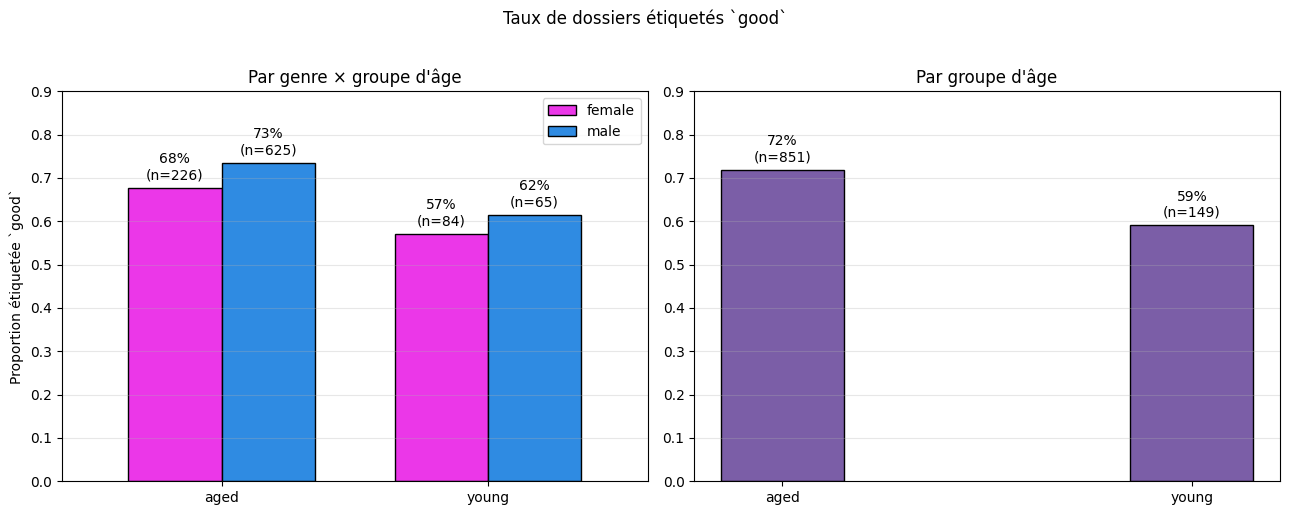

In [531]:
stats = (df.assign(good=(df['class'] == 'good').astype(int))                                        
            .groupby(['age_group', 'sex'])['good']                                                   
            .agg(taux='mean', n='count'))                                                            
taux      = stats['taux'].unstack()                                                                 
effectifs = stats['n'].unstack()                                                                    
                                                                                                    
marg = (df.assign(good=(df['class'] == 'good').astype(int))                                         
        .groupby('age_group')['good']
        .agg(taux='mean', n='count'))                                                             
                                                                                                    
fig, axes = plt.subplots(1, 2, figsize=(13, 5))                                                     

ax = axes[0]                                                                                        
taux.plot(kind='bar', ax=ax, color=["#EB37E8", "#2F8BE2"],
        edgecolor='black', width=0.7)                                                             
for container, sex in zip(ax.containers, taux.columns):
    labels = [f"{v:.0%}\n(n={effectifs.loc[ag, sex]})"                                              
            for ag, v in zip(taux.index, container.datavalues)]                                   
    ax.bar_label(container, labels=labels, padding=4, fontsize=10)                                  
ax.set_title("Par genre × groupe d'âge")                                                            
ax.set_ylabel("Proportion étiquetée `good`")                                                        
ax.set_xlabel("")                                                                                   
ax.set_ylim(0, 0.9)
ax.grid(axis='y', alpha=0.3)                                                                        
ax.legend(title="")                                                                                 
ax.tick_params(axis='x', rotation=0)
                                                                                                    
ax = axes[1]
ax.bar(marg.index, marg['taux'], color="#7B5EA7",                                                   
        edgecolor='black', width=0.3)                                                                
labels = [f"{v:.0%}\n(n={marg.loc[ag, 'n']})"
        for ag, v in zip(marg.index, marg['taux'])]                                               
ax.bar_label(ax.containers[0], labels=labels, padding=4, fontsize=10)
ax.set_title("Par groupe d'âge")                                                         
ax.set_xlabel("")                                                                                   
ax.set_ylabel("")                                                                                   
ax.set_ylim(0, 0.9)                                                                                 
ax.grid(axis='y', alpha=0.3)                                                                        
ax.tick_params(axis='x', rotation=0)                                                                

fig.suptitle("Taux de dossiers étiquetés `good`", y=1.02, fontsize=12)                              
plt.tight_layout()                                                                                  
plt.show()  

- Le taux d'étiquetage `good` est plus faible chez les jeunes (~59 %) que chez les adultes (~72 %), 
  soit un écart marginal d'environ 12 points. 
  
- Cet écart est stable entre les deux sexes (~11 points dans chaque), ce qui suggère un effet propre à l'âge non confondu par la composition genre × âge. 

- Le sous groupe des jeunes (n = 149) est plus petit que celui des personnes âgées (n = 851), les estimations seront donc plus incertaines . 

> Quand les taux de base diffèrent entre groupes (~12 points ici), les principales définitions de
fairness sont mutuellement incompatibles (Chouldechova 2017). Tout choix de mitigation imposera un 
arbitrage.


## 2. Baseline - Logistic Regression

> Pour la baseline, nous retenons une régression logistique L2 sans rééquilibrage de classes, modèle de référence en credit scoring pour sa simplicité, sa parcimonie et l'interprétabilité directe de ses coefficients en log-odds.

> Régression logistique sans rebalancing ni régularisation (`C → ∞`). Cette configuration minimale sert de référence pour la suite, les implications de ces choix (calibration, variance) seront discutées au moment où elles deviennent pertinentes (5 seuillage cost-sensitive, 7 mitigation).

In [532]:
X = df.drop(columns=['class', 'sex', 'age_group'])
A = (df['age'] < 25).astype(int)                                                                    


# Stratification jointe sur (Y, A)
strates = y.astype(str) + "_" + A.astype(str)

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
X, y, A,
test_size=0.3,
stratify=strates,
random_state=RANDOM_STATE
)

print(f"Train : {len(X_train)} lignes — {y_train.mean():.1%} good, {A_train.mean():.1%} jeunes")    
print(f"Test  : {len(X_test)} lignes  — {y_test.mean():.1%} good, {A_test.mean():.1%} jeunes")   

Train : 700 lignes — 70.0% good, 15.0% jeunes
Test  : 300 lignes  — 70.0% good, 14.7% jeunes


**Stratification jointe sur (Y, A)**
<br><br>

> Le dataset est séparé en train/test (70/30) avec une stratification sur la paire (cible, attribut sensible), où : </br>

- $Y$ désigne la variable cible.
- $A$ l’âge binarisé à 25 ans.

<br>

 Une stratification simple ne préserve qu'une marge :   

$$P_{\text{train}}(Y=1) \approx P_{\text{test}}(Y=1)$$

 La stratification jointe  préserve en plus la distribution **jointe** : 

$$P_{\text{train}}(Y=y, A=a) \approx P_{\text{test}}(Y=y, A=a), \quad \forall (y,a) \in \{0,1\}^2$$

En particulier, la part des jeunes solvables $P(Y=1, A=1)$ est conservée d'un split à l'autre.


> Avec $n_{\text{test}} = 300$ et seulement 14 % de jeunes, certains sous-groupes contiennent très peu d’individus (par exemple jeunes ∩ good, environ 26 observations). Sans stratification jointe sur $(Y, A)$, leur proportion peut varier fortement entre les splits, ce qui rend les métriques de fairness instables.

In [533]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()                   
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()                                
                                                                                                    
preprocessor = ColumnTransformer([                                                                  
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),                        
    ('num', StandardScaler(), num_cols),                                                            
])                                                                                                  
                                                                                                    
baseline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(
        C=1e10,                # régularisation effectivement nulle → calibration naturelle
        max_iter=5000,         # convergence plus lente sans pénalité
        solver='lbfgs',
        random_state=RANDOM_STATE,
    )),
])                                                                                            
                                                                                                    
baseline.fit(X_train, y_train)                                                                        

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [534]:
proba_test = baseline.predict_proba(X_test)[:, 1]   # P(Y=1 | x) = P(good | x)                      
                                                                            
print(f"Baseline entraînée. Forme proba_test : {proba_test.shape}, "                                
    f"plage : [{proba_test.min():.3f}, {proba_test.max():.3f}]") 

Baseline entraînée. Forme proba_test : (300,), plage : [0.025, 0.998]


In [535]:
def evaluate(model, X, y, label, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {                                                                                        
        'set':       label,
        'threshold': threshold,                                                                     
        'AUROC':     roc_auc_score(y, proba),                                                    
        'F1':        f1_score(y, pred),                                                             
        'Precision': precision_score(y, pred),                                                   
    }        

In [536]:
def evaluate_by_group(model, X, y, A, threshold=0.5):                                            
    proba = model.predict_proba(X)[:, 1]                                                            
    pred  = (proba >= threshold).astype(int)
    rows = []                                                                                       
    for g, label in [(1, 'jeune (A=1)'), (0, 'adulte (A=0)')]:                                      
        mask = (A == g)                     
        rows.append({                                                                               
            'group':     label,                                                                     
            'n':         mask.sum(),                                                                
            'AUROC':     roc_auc_score(y[mask], proba[mask]),                                       
            'F1':        f1_score(y[mask], pred[mask]),                                             
            'Precision': precision_score(y[mask], pred[mask]),                                      
            'Recall':    recall_score(y[mask], pred[mask]),
            'P(Ŷ=1)':   pred[mask].mean(),                                                          
        })                                                                                          
    return pd.DataFrame(rows).set_index('group').round(3)

In [537]:
results = pd.DataFrame([                                                                            
    evaluate(baseline, X_train, y_train, 'train', threshold=0.5),                                
    evaluate(baseline, X_test,  y_test,  'test',  threshold=0.5),                                   
]).set_index('set').round(3)                
                                                                                                    
results 

,threshold,AUROC,F1,Precision
set,,,,
train,0.5,0.839,0.854,0.817
test,0.5,0.775,0.827,0.803



> L'écart train/test sur l'AUROC est de 4.7 points, soit une généralisation correcte sans surapprentissage marqué.
>

In [538]:
evaluate_by_group(baseline, X_test, y_test, A_test, threshold=0.5)    

,n,AUROC,F1,Precision,Recall,P(Ŷ=1)
group,,,,,,
jeune (A=1),44,0.733,0.727,0.69,0.769,0.659
adulte (A=0),256,0.778,0.841,0.82,0.864,0.758


### 3.1 Le contexte bancaire et l'asymétrie des coûts </br>

a. Pourquoi toutes les erreurs ne se valent pas ? </br>

Le scoring crédit n’est pas un problème de classification neutre. La décision du modèle engage directement le bilan de l’institution financière.

Le seuil $\tau$ utilisé jusqu’ici ($0.5$) est celui par défaut de scikit-learn, mais il suppose implicitement que les deux types d’erreur ont le même coût. </br> 

Or, dans un problème de crédit, ce n’est pas le cas : refuser un bon client (perte d’opportunité commerciale) et accorder un crédit à un client risqué (perte potentielle du capital prêté) n’ont pas le même impact économique. </br>
</br> </br>

b. La matrice de coût du German Credit

> Le German Credit Dataset modélise explicitement cette asymétrie à travers la matrice de coût suivante : 

  $$                                                                                                                      
  C =
  \begin{pmatrix}                                                                                                         
  0 & 1 \\                                                                                                                
  5 & 0
  \end{pmatrix}                                                                                                           
  $$


Où :
- Un faux positif (accorder un crédit à un client risqué) coûte ainsi 5 fois plus qu’un faux négatif (refuser un client solvable).

###  3.2 Du coût au seuil bayésien optimal

> La matrice de coût ne modifie pas seulement l’évaluation du modèle = elle change également la règle de décision. Le seuil optimal devient alors celui qui minimise le coût attendu des décisions de crédit.

</br> </br>


a. Coût attendu des deux décisions 

</br> </br> 
$$
\mathbb{E}[C \mid \text{accepter}] = c_{TP} \cdot p + c_{FP} \cdot (1-p) = c_{FP} \cdot (1-p)
$$

$$
\mathbb{E}[C \mid \text{refuser}] = c_{FN} \cdot p + c_{TN} \cdot (1-p) = c_{FN} \cdot p
$$

</br>

<span style="color:#7F8C8D;">

Soit $p = P(Y=1 \mid x)$ la probabilité estimée que le client soit solvable. </br>
(On utilise $c_{TP} = c_{TN} = 0$ : les bonnes décisions sont à coût nul.)

</span> </br> </br> 




b. Règle de décision optimale. </br> </br></br> La banque accorde le crédit uniquement lorsque le coût attendu de l'acceptation est inférieur à celui du refus :</br></br>  

$$
\mathbb{E}[C \mid \text{accepter}] < \mathbb{E}[C \mid \text{refuser}]
$$

ce qui donne :

$$
c_{FP} \cdot (1-p) < c_{FN} \cdot p
$$

En isolant $p$ :

$$
p > \frac{c_{FP}}{c_{FP} + c_{FN}}
$$

Le seuil bayésien optimal est donc :

$$
\boxed{\tau^\star = \frac{c_{FP}}{c_{FP} + c_{FN}}}
$$
</br> </br> </br>

c. Application au German Credit. </br> </br></br>   Avec $c_{FP} = 5$ et $c_{FN} = 1$ :

$$
\boxed{\tau^\star = \frac{5}{5+1} = \frac{5}{6} \approx 0{,}833}
$$

> Le seuil $\tau^\star$ minimise le coût attendu des décisions de crédit. Il servira donc de seuil de référence pour l’évaluation des métriques de fairness dans la suite de l’étude.

Cette étape 

In [539]:
C_FP, C_FN = 5, 1
tau_star = C_FP / (C_FP + C_FN)         
                                                            
print(f"τ★= {tau_star:.2f}")                                                                              

τ★= 0.83


In [540]:
def cost_at(tau):                                                                                                                                                                                                                                      
    y_pred = (proba_test >= tau).astype(int)                                                                                                                                                                                                           
    fp = ((y_pred == 1) & (y_test == 0)).sum()                                                                                                                                                                                                         
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    return (C_FP * fp + C_FN * fn) / len(y_test)          

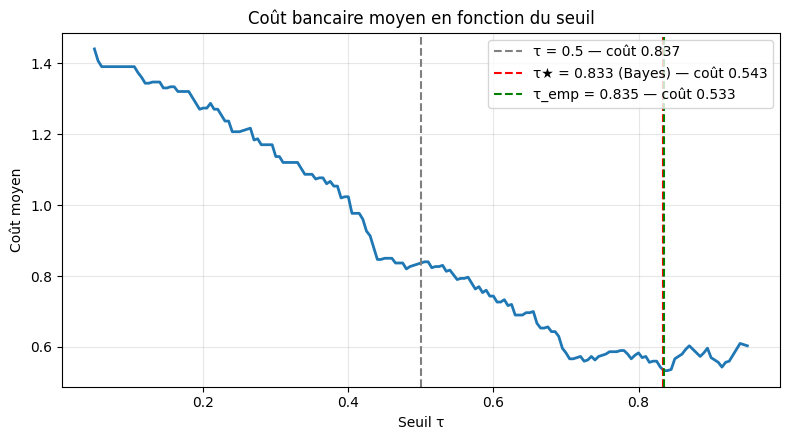

In [541]:
taus  = np.linspace(0.05, 0.95, 181)                                                                                                                                                                                                                   
costs = np.array([cost_at(t) for t in taus])                                                                                                                                                                                                           
tau_emp  = taus[np.argmin(costs)]                                                                                                                                                                                                                      
cost_emp = costs.min()                                                                                                                                                                                                                                 
cost_star = cost_at(tau_star)                                                                                                                                                                                                                        
cost_05   = cost_at(0.5)                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                    
# Affichage                                                                                                                                                                                                                                            
fig, ax = plt.subplots(figsize=(8, 4.5))                                                                                                                                                                                                             
ax.plot(taus, costs, color='tab:blue', lw=2)                                                                                                                                                                                                           
                                                                                                                                                                                                                                                        
ax.axvline(0.5,      color='gray',  ls='--', lw=1.5, label=f'τ = 0.5 — coût {cost_05:.3f}')                                                                                                                                                            
ax.axvline(tau_star, color='red',   ls='--', lw=1.5, label=f'τ★ = {tau_star:.3f} (Bayes) — coût {cost_star:.3f}')                                                                                                                                      
ax.axvline(tau_emp,  color='green', ls='--', lw=1.5, label=f'τ_emp = {tau_emp:.3f} — coût {cost_emp:.3f}')                                                                                                                                             
                                                                                                                                                                                                                                                        
ax.set_xlabel('Seuil τ'); ax.set_ylabel('Coût moyen')                                                                                                                                                                                                  
ax.set_title("Coût bancaire moyen en fonction du seuil")                                                                                                                                                                                               
ax.legend(loc='upper right'); ax.grid(alpha=0.3)                                                                                                                                                                                                       
plt.tight_layout(); plt.show()                                                                                                                                                                                                                            

In [542]:
results = pd.DataFrame({                                                                                                                                                                                                                               
    'Origine':            ['Défaut sklearn', 'Bayes (théorique)', 'Empirique (test)'],                                                                                                                                                               
    'Coût moyen':         [round(cost_05, 4), round(cost_star, 4), round(cost_emp, 4)],                                                                                                                                                                
    'Réduction vs τ=0.5': ['—',                                                                                                                                                                                                                        
                            f"{(1 - cost_star/cost_05)*100:+.1f} %",                                                                                                                                                                                    
                            f"{(1 - cost_emp/cost_05)*100:+.1f} %"],                                                                                                                                                                                    
}, index=pd.Index([0.5, round(tau_star, 3), round(tau_emp, 3)], name='τ'))                                                                                                                                                                           
                                                                                                                                                                                                                                                        
results         

,Origine,Coût moyen,Réduction vs τ=0.5
τ,,,
0.500,Défaut sklearn,0.8367,—
0.833,Bayes (théorique),0.5433,+35.1 %
0.835,Empirique (test),0.5333,+36.3 %


In [543]:
print(f"Δτ (τ★ − τ_emp) = {tau_star - tau_emp:+.3f}  →  τ_emp aligné sur τ★ Bayes")                                                                                                                                                                    

Δτ (τ★ − τ_emp) = -0.002  →  τ_emp aligné sur τ★ Bayes


**Lecture.** $\tau^\star = 0{,}833$ et $\tau_{\text{emp}} = 0{,}835$ coïncident ($\Delta\tau = -0{,}002$),  la règle bayésienne s'applique directement à nos scores. </br> Adopter $\tau^\star$ réduit le coût bancaire de 35 % par rapport au défaut sklearn. </br>  Ce gain économique a un prix en équité, quantifié dans la section suivante.

## 3. Métrique de fairness : 

> **Convention utilisée pour la suite :**
>
> - $A = 1$ : clients jeunes ($\leq 25$ ans) ;
> - $A = 0$ : clients adultes ($> 25$ ans).
>
> Les clients adultes constituent donc le groupe de référence, et les clients jeunes le groupe potentiellement défavorisé.


In [544]:
threshold = 0.833                                                                                                      
y_pred = (proba_test >= threshold).astype(int)     

<u> a. Demographic Parity (DP) : </u> <br>                                                          
**Objectif :** vérifier que le modèle accorde le crédit au même taux dans les deux groupes.                             
                                                                                                                          
  $$                                                                                                                      
  \Delta\text{DP} = P(\hat{Y}=1 \mid A=1) - P(\hat{Y}=1 \mid A=0)                                                         
  $$    

In [545]:
def compute_dp(proba, A, threshold=0.5, verbose=True):
    y_pred = (proba >= threshold).astype(int)
                                            
    mask_jeune  = (A == 1)                  
    mask_adulte = (A == 0)              
                                                                                                                        
    DP_jeune  = y_pred[mask_jeune].mean()                                                                               
    DP_adulte = y_pred[mask_adulte].mean()                                                                              
    delta_DP  = DP_jeune - DP_adulte                                                                                    
                                                                                                                        
    if verbose:
        print(f"Seuil τ = {threshold}")                                                                                 
        print(f"DP jeune  : {DP_jeune:.3f}  (n={mask_jeune.sum()})")
        print(f"DP adulte : {DP_adulte:.3f}  (n={mask_adulte.sum()})")                                                  
        print(f"ΔDP       : {delta_DP:+.3f}")                                                                           
                                        
    return delta_DP 

In [546]:
delta_DP = compute_dp(proba_test, A_test, threshold=0.833)       

Seuil τ = 0.833
DP jeune  : 0.250  (n=44)
DP adulte : 0.516  (n=256)
ΔDP       : -0.266


Seuil τ = 0.833
DP jeune  : 0.182  (n=44)
DP adulte : 0.453  (n=256)
ΔDP       : -0.271


La règle des "4/5" est un principe juridique <span style="color:#4A90E2;"> américain (EEOC) </span> qui évalue si un système de sélection est équitable.


<br> Pour qu'un système soit équitable il faut qu'il respecte le ratio suivant :                                                                                                                      

  $$                                                                                                                      
  \frac{\text{DP}_{\text{défavorisé}}}{\text{DP}_{\text{favorisé}}} \geq 0.8
  $$

$$
\frac{0{,}250}{0{,}516} \approx 0{,}48 \;<\; 0{,}80
$$



Ainsi la règle est non respectée.                                                                                          
Les jeunes sont défavorisés (taux d'accord plus bas) avec 26,6 points d'écart
.

> <span style="color:#D4AC0D;"> <u> Remarque </span> </u> <br><br> Dans le cadre bancaire, égaliser DP n'a pas d'intérêt opérationnel.<br><br> On forcerait la banque à accorder le crédit à des jeunes en incapacité réelle de rembourser, et leurs défauts alimenteraient négativement l'historique (feedback loop) aggravant le biais au lieu de le corriger. <br> <br> (*disparate impact amplification* via *selection bias under intervention*, Ensign et al. 2018).

<u> b. Equal Opportunity (EOpp) : </u> <br><br>
**Objectif** : Vérifier que parmi les vrais bons clients (Y=1), le modèle sélectionne autant de personnes dans chaque groupe.

  $$
  \Delta\text{EOpp} = P(\hat{Y}=1 \mid Y=1, A=1) - P(\hat{Y}=1 \mid Y=1, A=0)
  $$


EOpp est plus intéressente pour notre cas de figure, car elle ne demande l'égalité que parmi les vrais bons clients (Y=1). <br>
La banque n'est donc pas forcée d'accorder à des défaillants (contrairement à DP), mais doit traiter à parts égales les jeunes et les adultes qui "rembourseraient effectivement" ( selon l'étiquette good - biaisé par le pov de l'agent comme vu plus haut ).

 EOpp protège l'accès ("ai-je la même chance qu'un autre ?").<br>


In [547]:
def compute_eopp(proba, y_true, A, threshold=0.5, verbose=True):
    y_pred = (proba >= threshold).astype(int)
                                            
    mask_jeune  = (A == 1) & (y_true == 1)
    mask_adulte = (A == 0) & (y_true == 1)
                                                                                                                        
    TPR_jeune  = y_pred[mask_jeune].mean()  
    TPR_adulte = y_pred[mask_adulte].mean()                                                                             
    delta_EOpp = TPR_jeune - TPR_adulte                                                                                 
                                                                                                                        
    if verbose:                         
        print(f"Seuil τ = {threshold}")                                                                                 
        print(f"TPR jeune  : {TPR_jeune:.3f}  (n={mask_jeune.sum()})")                                                  
        print(f"TPR adulte : {TPR_adulte:.3f}  (n={mask_adulte.sum()})")
        print(f"ΔEOpp      : {delta_EOpp:+.3f}")                                                                        
                                                                                                                        
    return delta_EOpp 

In [548]:
delta_EOpp = compute_eopp(proba_test, y_test, A_test, threshold=0.833)                                                 

Seuil τ = 0.833
TPR jeune  : 0.385  (n=26)
TPR adulte : 0.636  (n=184)
ΔEOpp      : -0.251


In [579]:
def compute_eopp(proba, y, A, threshold_young=0.833, threshold_old=0.833,                                                                
                c_fp=5, c_fn=1, verbose=True):
    """                                                                                                                                  
    Calcule |ΔEOpp| + coût total (matrice c_FP:c_FN) avec seuils par groupe.
    """                                                                                                                                  
    p = np.asarray(proba); y = np.asarray(y); A = np.asarray(A)
                                                                                                                                        
    def block(mask, tau):
        yhat = (p[mask] >= tau).astype(int); yy = y[mask]                                                                                
        TP = ((yhat==1)&(yy==1)).sum(); FP = ((yhat==1)&(yy==0)).sum()
        FN = ((yhat==0)&(yy==1)).sum()                                                                                                   
        P  = (yy==1).sum()                                                                                                               
        tpr  = TP/P if P else 0.0                                                                                                        
        cost = c_fp*FP + c_fn*FN                                                                                                         
        return tpr, int(TP), int(P), int(FP), int(FN), int(cost)                                                                         

    tpr_y, TP_y, P_y, FP_y, FN_y, cost_y = block(A==1, threshold_young)                                                                  
    tpr_o, TP_o, P_o, FP_o, FN_o, cost_o = block(A==0, threshold_old)
                                                                                                                                        
    delta = abs(tpr_y - tpr_o)                                                                                                           
    cost_tot = cost_y + cost_o
                                                                                                                                        
    if verbose: 
        print(f"Jeunes  (τ={threshold_young:.3f}) : TPR={tpr_y:.3f} ({TP_y}/{P_y})  "
            f"FP={FP_y} FN={FN_y}  Coût={cost_y}")                                                                                     
        print(f"Adultes (τ={threshold_old:.3f}) : TPR={tpr_o:.3f} ({TP_o}/{P_o})  "                                                      
            f"FP={FP_o} FN={FN_o}  Coût={cost_o}")                                                                                     
        print(f"|ΔEOpp|     = {delta:.3f}")                                                                                              
        print(f"Coût total  = {cost_tot}  (c_FP={c_fp}, c_FN={c_fn})")                                                                   
                
    return {"delta_eopp": delta,                                                                                                         
            "cost_total": cost_tot,
            "cost_young": cost_y, "cost_old": cost_o,                                                                                    
            "tpr_young": tpr_y, "tpr_old": tpr_o}
                                                                                                                                        
# Seuil uniforme bayésien
compute_eopp(proba_test, y_test, A_test,
            threshold_young=5/6, threshold_old=5/6)                                                                                     

# Seuils différenciés                                                                                                                    
compute_eopp(proba_test, y_test, A_test,
            threshold_young=0.823, threshold_old=0.879)  

Jeunes  (τ=0.833) : TPR=0.385 (10/26)  FP=1 FN=16  Coût=21
Adultes (τ=0.833) : TPR=0.636 (117/184)  FP=15 FN=67  Coût=142
|ΔEOpp|     = 0.251
Coût total  = 163  (c_FP=5, c_FN=1)
Jeunes  (τ=0.823) : TPR=0.385 (10/26)  FP=2 FN=16  Coût=26
Adultes (τ=0.879) : TPR=0.484 (89/184)  FP=11 FN=95  Coût=150
|ΔEOpp|     = 0.099
Coût total  = 176  (c_FP=5, c_FN=1)


{'delta_eopp': np.float64(0.09908026755852839),
 'cost_total': 176,
 'cost_young': 26,
 'cost_old': 150,
 'tpr_young': np.float64(0.38461538461538464),
 'tpr_old': np.float64(0.483695652173913)}

In [576]:
def compute_eopp(proba, y, A, threshold_young=0.833, threshold_old=0.833, verbose=True):                                                 
    """
    Calcule |ΔEOpp| = |TPR_jeunes - TPR_adultes| avec seuils par groupe.                                                                 
                                                                                                                                        
    proba             : scores P̂(Y=1 | X)                                                                                                
    y                 : labels réels (1 = good, 0 = bad)                                                                                 
    A                 : attribut sensible (1 = jeune, 0 = adulte)                                                                        
    threshold_young   : seuil τ appliqué aux jeunes (A=1)
    threshold_old     : seuil τ appliqué aux adultes (A=0)                                                                               
    """         
    p = np.asarray(proba); y = np.asarray(y); A = np.asarray(A)                                                                          
                                                                                                                                        
    def tpr(mask, tau):
        yhat = (p[mask] >= tau).astype(int)                                                                                              
        yy   = y[mask]
        P    = (yy == 1).sum()
        TP   = ((yhat == 1) & (yy == 1)).sum()                                                                                           
        return TP / P if P else 0.0, int(TP), int(P)
                                                                                                                                        
    tpr_y, TP_y, P_y = tpr(A == 1, threshold_young)                                                                                      
    tpr_o, TP_o, P_o = tpr(A == 0, threshold_old)                                                                                        
    delta = abs(tpr_y - tpr_o)                                                                                                           
                                                                                                                                        
    if verbose:
        print(f"Jeunes  (τ={threshold_young:.3f}) : TPR = {tpr_y:.3f}   ({TP_y}/{P_y})")                                                 
        print(f"Adultes (τ={threshold_old:.3f}) : TPR = {tpr_o:.3f}   ({TP_o}/{P_o})")                                                   
        print(f"|ΔEOpp| = {delta:.3f}")                                                                                                  
                                                                                                                                        
    return delta                                                                                                                         
                

# Même seuil partout                                                                                                                     
compute_eopp(proba_test, y_test, A_test, threshold_young=5/6, threshold_old=5/6)
                                                                                                                                        
# Seuil plus bas pour les jeunes (Hardt-like)                                                                                            
compute_eopp(proba_test, y_test, A_test, threshold_young=0.60, threshold_old=5/6)                                                        
                                                                                                                                        
# Balayage rapide pour trouver le τ_jeunes qui égalise EOpp                                                                              
for t in np.arange(0.40, 0.90, 0.02):
    d = compute_eopp(proba_test, y_test, A_test,                                                                                         
                    threshold_young=t, threshold_old=5/6, verbose=False)
    print(f"τ_jeunes={t:.2f}  |ΔEOpp|={d:.3f}")   

Jeunes  (τ=0.833) : TPR = 0.385   (10/26)
Adultes (τ=0.833) : TPR = 0.636   (117/184)
|ΔEOpp| = 0.251
Jeunes  (τ=0.600) : TPR = 0.769   (20/26)
Adultes (τ=0.833) : TPR = 0.636   (117/184)
|ΔEOpp| = 0.133
τ_jeunes=0.40  |ΔEOpp|=0.249
τ_jeunes=0.42  |ΔEOpp|=0.210
τ_jeunes=0.44  |ΔEOpp|=0.210
τ_jeunes=0.46  |ΔEOpp|=0.210
τ_jeunes=0.48  |ΔEOpp|=0.210
τ_jeunes=0.50  |ΔEOpp|=0.133
τ_jeunes=0.52  |ΔEOpp|=0.133
τ_jeunes=0.54  |ΔEOpp|=0.133
τ_jeunes=0.56  |ΔEOpp|=0.133
τ_jeunes=0.58  |ΔEOpp|=0.133
τ_jeunes=0.60  |ΔEOpp|=0.133
τ_jeunes=0.62  |ΔEOpp|=0.095
τ_jeunes=0.64  |ΔEOpp|=0.095
τ_jeunes=0.66  |ΔEOpp|=0.056
τ_jeunes=0.68  |ΔEOpp|=0.018
τ_jeunes=0.70  |ΔEOpp|=0.059
τ_jeunes=0.72  |ΔEOpp|=0.059
τ_jeunes=0.74  |ΔEOpp|=0.136
τ_jeunes=0.76  |ΔEOpp|=0.136
τ_jeunes=0.78  |ΔEOpp|=0.174
τ_jeunes=0.80  |ΔEOpp|=0.251
τ_jeunes=0.82  |ΔEOpp|=0.251
τ_jeunes=0.84  |ΔEOpp|=0.290
τ_jeunes=0.86  |ΔEOpp|=0.405
τ_jeunes=0.88  |ΔEOpp|=0.405


In [577]:
compute_eopp(proba_test, y_test, A_test,threshold_young=0.823, threshold_old=0.879)                                                                                 
                                                                                                                                                                                                                                                                                
import numpy as np                                                                                                                       
import pandas as pd

p = np.asarray(proba_test); y_arr = np.asarray(y_test); A_arr = np.asarray(A_test)                                                       
TAU_Y, TAU_O = 0.823, 0.879
                                                                                                                                        
def block(mask, tau):
    yhat = (p[mask] >= tau).astype(int); y = y_arr[mask]                                                                                 
    TP=((yhat==1)&(y==1)).sum(); FP=((yhat==1)&(y==0)).sum()                                                                             
    FN=((yhat==0)&(y==1)).sum(); TN=((yhat==0)&(y==0)).sum()
    P,N=(y==1).sum(),(y==0).sum()                                                                                                        
    return {"τ":tau, "TP":int(TP),"FP":int(FP),"FN":int(FN),"TN":int(TN),                                                                
            "TPR":TP/P if P else 0, "FPR":FP/N if N else 0,                                                                              
            "PPV":TP/(TP+FP) if (TP+FP) else 0, "Coût": int(5*FP+FN)}                                                                    
                                                                                                                                        
rows = {"Jeunes":  block(A_arr==1, TAU_Y),                                                                                               
        "Adultes": block(A_arr==0, TAU_O)}                                                                                               
df = pd.DataFrame(rows).T                                                                                                                

display(df.style.format({"τ":"{:.3f}","TPR":"{:.3f}","FPR":"{:.3f}","PPV":"{:.3f}"})                                                     
                .set_caption(f"Seuils différenciés — τ_jeunes={TAU_Y}, τ_adultes={TAU_O}"))
                                                                                                                                        
print(f"\n|ΔEOpp| = {abs(df.loc['Jeunes','TPR'] - df.loc['Adultes','TPR']):.3f}")                                                        
print(f"|ΔFPR|  = {abs(df.loc['Jeunes','FPR'] - df.loc['Adultes','FPR']):.3f}")                                                          
print(f"|ΔPP|   = {abs(df.loc['Jeunes','PPV'] - df.loc['Adultes','PPV']):.3f}")                                                          
print(f"Coût total = {int(df['Coût'].sum())}")                                                                                           
                                                

Jeunes  (τ=0.823) : TPR = 0.385   (10/26)
Adultes (τ=0.879) : TPR = 0.484   (89/184)
|ΔEOpp| = 0.099


,τ,TP,FP,FN,TN,TPR,FPR,PPV,Coût
Jeunes,0.823,10.000000,2.000000,16.000000,16.000000,0.385,0.111,0.833,26.000000
Adultes,0.879,89.000000,11.000000,95.000000,61.000000,0.484,0.153,0.890,150.000000



|ΔEOpp| = 0.099
|ΔFPR|  = 0.042
|ΔPP|   = 0.057
Coût total = 176


<u> Analyse du signal : </u>

- À τ\* = 0,833, le modèle rate 62 % des bons clients jeunes contre 36 % des adultes seulement.
-  <span style="color:red;"> Près de 1,7× plus d'erreurs </span> sur les jeunes solvables.
- |ΔEOpp| = 0,251 dépasse largement le seuil conventionnel de $0{,}10$ (Friedler 2019, AIF360), sans constituer une violation au sens juridique strict (aucun ratio normatif n'existe pour EOpp, contrairement à DP).

<u>
⚠️&nbsp;&nbsp;&nbsp;Caveat fiabilité !
</u>
<br><br> 

- TPR jeune est calculé sur 26 personnes seulement . La valeur dépend fortement de quelles 26 personnes ont été tirées. Un autre split aurait pu donner 0.45 ou 0.70 sans que le modèle ait changé.  C'est le bruit d'échantillonnage.                                                                                                                     

- Pour le quantifier, on rééchantillonne le test set 1000 fois (bootstrap) et on rapporte trois indicateurs complémentaires - un intervalle de confiance à 95 % et 90 % ainssi qu'une probabilité directionnelle P(Δ<0).  

In [549]:
def bootstrap_ci(metric_fn, y, yhat, A, n_boot=1000, seed=RANDOM_STATE):                                                

    rng = np.random.default_rng(seed)                                                                                   
    n = len(y)                                                                                                          
    samples = []    

    for _ in range(n_boot):   

        idx = rng.integers(0, n, size=n)                                                                                
        d = metric_fn(y[idx], yhat[idx], A[idx])   

        if d is not None:                                                                                               
            samples.append(d)      

    s = np.array(samples) 
                                                                                                  
    return {                                                                                                            
        'delta':    metric_fn(y, yhat, A),  
        'ic95':     tuple(np.percentile(s, [2.5, 97.5])),                                                               
        'ic90':     tuple(np.percentile(s, [5,   95])),                                                                 
        'p_dir':    (s < 0).mean() if metric_fn(y, yhat, A) < 0 else (s > 0).mean(),                                    
    }      

In [550]:
def show_ci(name, delta, r): 
                                                                                               
    return pd.DataFrame({                                                                                               
        'Δ':                   [round(delta, 3)],                                                                       
        'IC 95%':              [f"[{r['ic95'][0]:+.3f}, {r['ic95'][1]:+.3f}]"],
        'IC 90%':              [f"[{r['ic90'][0]:+.3f}, {r['ic90'][1]:+.3f}]"],                                         
        'P(Δ dans sens obs.)': [round(r['p_dir'], 3)],
    }, index=[name])                                                                                                    
            

In [551]:
y_test_np = np.asarray(y_test)
A_test_np = np.asarray(A_test)  

show_ci("ΔEOpp", delta_EOpp, bootstrap_ci(                                                                              
    lambda y, yhat, a: yhat[(a==1)&(y==1)].mean() - yhat[(a==0)&(y==1)].mean(),
    y_test_np, y_pred, A_test_np                                                                                        
))                                          

,Δ,IC 95%,IC 90%,P(Δ dans sens obs.)
ΔEOpp,-0.251,"[-0.450, -0.053]","[-0.416, -0.088]",0.994


- Le signal est significatif au seuil 5 % . Le 0 exclut entièrement zéro. </br>
- Le signal est significatif au seuil 10 %. </br>
- On obtient une probabilité directionnelle tq P(Δ<0) = 1 indiquant que 100% des bootstraps sont strictement négatifs.
 <br> <br> 

> On peut donc considérer le signal comme fiable malgré l'effectif réduit (n=26).


<u> c.  Equalized Odds (EOdds) : </u> <br><br>
 **Objectif** : vérifier que les deux taux d'erreur sont égaux entre groupes = refus à tort sur les vrais good (TPR),
  **et** accord à tort sur les vrais bad (FPR).
Soit s'assurer de ne pas refuser plus de bons clients ni accorder plus de crédits à de mauvais clients selon le groupe.


  $$                                                                                                                      
  \Delta\text{EOdds} = \max(|\Delta\text{TPR}|,\ |\Delta\text{FPR}|)                                                      
  $$            

In [552]:
def compute_eodds(proba, y_true, A, threshold=0.5, verbose=True):
    y_pred = (proba >= threshold).astype(int)
                                                                                                                        
    mask_j_good = (A == 1) & (y_true == 1)  
    mask_a_good = (A == 0) & (y_true == 1) 

    TPR_j = y_pred[mask_j_good].mean()                                                                                  
    TPR_a = y_pred[mask_a_good].mean()  

    delta_TPR = TPR_j - TPR_a                                                                                           
                                                                                                                        
    mask_j_bad = (A == 1) & (y_true == 0)                                                                               
    mask_a_bad = (A == 0) & (y_true == 0)

    FPR_j = y_pred[mask_j_bad].mean()                                                                                   
    FPR_a = y_pred[mask_a_bad].mean()     

    delta_FPR = FPR_j - FPR_a               
                                                                                                                        
    delta_EOdds = max(abs(delta_TPR), abs(delta_FPR))                                                                   
                                                                                                                        
    if verbose:
        print(f"Seuil τ = {threshold}")                       

        print("\n ")
        print(f"TPR jeune  : {TPR_j:.3f}  (n={mask_j_good.sum()})   ΔTPR = {delta_TPR:+.3f}")                           
        print(f"TPR adulte : {TPR_a:.3f}  (n={mask_a_good.sum()}) ")     

        print("\n ")
        print(f"FPR jeune  : {FPR_j:.3f}  (n={mask_j_bad.sum()})   ΔFPR = {delta_FPR:+.3f}")                            
        print(f"FPR adulte : {FPR_a:.3f}  (n={mask_a_bad.sum()}) ")

        print(f"\nΔEOdds     : {delta_EOdds:.3f}   (= max(|ΔTPR|, |ΔFPR|))")                                              
                                                                                                                        
    return delta_EOdds    

In [553]:
delta_EOdds = compute_eodds(proba_test, y_test, A_test, threshold=0.833)                                             

Seuil τ = 0.833

 
TPR jeune  : 0.385  (n=26)   ΔTPR = -0.251
TPR adulte : 0.636  (n=184) 

 
FPR jeune  : 0.056  (n=18)   ΔFPR = -0.153
FPR adulte : 0.208  (n=72) 

ΔEOdds     : 0.251   (= max(|ΔTPR|, |ΔFPR|))


<u> Analyse du signal : </u>

- Sur les bons clients on rate près de 1.7× plus les jeunes (ΔTPR = −0.251) par rapport aux adultes, et sur les mauvais on en accepte à tort 3.7× moins (ΔFPR = −0.153). <br>
- Le modèle est donc **plus strict avec les jeunes des deux côtés**, il leur dit "non" plus souvent, qu'ils méritent un crédit ou non.

- Ce qui est une bonne nouvelle pour les jeunes car ils sont au moins protégés contre les accords à tort, qui risqueraient d'aggraver leur historique de crédit et les pénaliser à l'avenir. Si le modèle accordait massivement des crédits aux jeunes mauvais payeurs, leurs défauts s'inscriraient dans l'historique de crédit du groupe, alimentant les futures décisions du modèle qui apprendrait à *justifier* statistiquement leur exclusion. C'est exactement le mécanisme documenté par Ensign et al. (2018) en *predictive policing*, transposable au scoring crédit.

<div align="center">
<img src="im.png" width="900"/>
</div>



> EOdds est dominé par le TPR , c'est la même violation qu'EOpp, avec un FPR plus favorable côté jeunes. La mitigation ciblera donc EOpp (faire monter le TPR des jeunes), tout en gardant à l'œil le FPR pour ne pas annuler cet avantage en sur-acceptant des jeunes risqués.                                                                       


In [554]:
y_pred = (proba_test >= tau_star).astype(int)                                                                                                                                                                                                        
y_test_np = np.asarray(y_test)                                                                                                                                                                                                                         
A_test_np = np.asarray(A_test)

In [555]:
fpr_jeune  = y_pred[(A_test_np==1) & (y_test_np==0)].mean()                                                                                                                                                                                          
fpr_adulte = y_pred[(A_test_np==0) & (y_test_np==0)].mean()                                                                                                                                                                                            
delta_FPR  = fpr_jeune - fpr_adulte                                                                                                                                                                                                                    
print(f"FPR jeune  : {fpr_jeune:.3f}  (n={((A_test_np==1)&(y_test_np==0)).sum()})")                                                                                                                                                                    
print(f"FPR adulte : {fpr_adulte:.3f}  (n={((A_test_np==0)&(y_test_np==0)).sum()})")                                                                                                                                                                   
print(f"ΔFPR       : {delta_FPR:+.3f}\n")     

FPR jeune  : 0.056  (n=18)
FPR adulte : 0.208  (n=72)
ΔFPR       : -0.153



In [556]:
show_ci("ΔFPR", delta_FPR, bootstrap_ci(                                                                                                                                                                                                               
    lambda y, yhat, a: yhat[(a==1)&(y==0)].mean() - yhat[(a==0)&(y==0)].mean(),                                                                                                                                                                        
    y_test_np, y_pred, A_test_np                                                                                                                                                                                                                       
))          

,Δ,IC 95%,IC 90%,P(Δ dans sens obs.)
ΔFPR,-0.153,"[-0.278, -0.004]","[-0.264, -0.035]",0.976


- Le signal est significatif au seuil 5 % . Le 0 exclut entièrement zéro. </br>
- Le signal est significatif au seuil 10 %. </br>
- On obtient une probabilité directionnelle tq P(Δ<0) = 0.976 indiquant que 97.6% des bootstraps sont strictement négatifs.
 <br> <br> 

La violation d'Equalized Odds est asymétrique. </br>  Elle pèse principalement sur les vrais bons jeunes (refusés à un taux 30 points inférieur à celui des vrais bons adultes). La mitigation prioritaire est donc le rétablissement de TPR, ce qui motive le choix d'EOpp comme métrique cible . 

<u> d.  Predictive Parity (PP) : </u> <br><br>

**Objectif.** Vérifier qu'un dossier accepté a la même probabilité d'être un bon client dans les deux groupes.




 $$                                          
  \Delta\text{PP} = P(Y = 1 \mid \hat{Y} = 1,\ A = 1) - P(Y = 1 \mid \hat{Y} = 1,\ A = 0)
  $$   


  PP protège la signification ("ce qu'on dit de moi vaut-il la même chose ?").

- Théorème d'impossibilité (Chouldechova 2017)
                                                                                                                          
  Dès que les **taux de base diffèrent** entre les groupes (chez nous : 59% de bons jeunes vs 72% de bons adultes), il est
   **mathématiquement impossible** de satisfaire simultanément :                                                          
  - $\Delta\text{PP} = 0$
  - $\Delta\text{EOdds} = 0$                                                               
                                                                                                                          
  C'est le cœur du débat **COMPAS 2016** (Northpointe vs ProPublica) : les deux camps avaient raison statistiquement, mais ne défendaient pas la même conception de la fairness. 

In [557]:
def compute_pp(proba, y_true, A, threshold=0.5, verbose=True):                                                          
    y_pred = (proba >= threshold).astype(int)                                                                           
                                                                                                                        
    mask_jeune_pos  = (A == 1) & (y_pred == 1)                                                                          
    mask_adulte_pos = (A == 0) & (y_pred == 1)                                                                          
                                                                                                                        
    PP_jeune  = y_true[mask_jeune_pos].mean()                                                                           
    PP_adulte = y_true[mask_adulte_pos].mean()                                                                          
    delta_PP  = PP_jeune - PP_adulte                                                                                    
                                                                                                                        
    if verbose:
        print(f"Seuil τ = {threshold}")                                                                                 
        print(f"PP jeune  : {PP_jeune:.3f}  (n={mask_jeune_pos.sum()})")                                                
        print(f"PP adulte : {PP_adulte:.3f}  (n={mask_adulte_pos.sum()})")                                              
        print(f"ΔPP       : {delta_PP:+.3f}")                                                                           
                                                                                                                        
    return delta_PP     

In [558]:
delta_PP = compute_pp(proba_test, y_test, A_test, threshold=0.83)                                                        

Seuil τ = 0.83
PP jeune  : 0.909  (n=11)
PP adulte : 0.886  (n=132)
ΔPP       : +0.023


**Lecture des résultats.**

À τ\* = 0,833, parmi les clients acceptés, le modèle a raison dans 91 % des cas chez les jeunes contre 89 % chez les adultes. ΔPP = +0,023.

Trois informations à retenir :

1. **Les acceptations à τ\* sont fiables dans les deux groupes** : ~9 décisions favorables sur 10 sont correctes. Le seuil sélectif filtre efficacement les profils à risque.

2. **L'écart entre groupes a quasiment disparu**. À τ\*, la *predictive parity* est satisfaite : un crédit accordé signifie la même chose pour un jeune et pour un adulte.




In [559]:
def pp_metric(y, yhat, A):
    mask_j = (A == 1) & (yhat == 1)
    mask_a = (A == 0) & (yhat == 1)
    if mask_j.sum() == 0 or mask_a.sum() == 0:
        return None
    return y[mask_j].mean() - y[mask_a].mean()

y_pred_83 = (proba_test >= 0.833).astype(int)
result = bootstrap_ci(pp_metric, y_test_np, y_pred_83, A_test_np)
show_ci("ΔPP à τ*", 0.023, result)

,Δ,IC 95%,IC 90%,P(Δ dans sens obs.)
ΔPP à τ*,0.023,"[-0.185, +0.156]","[-0.145, +0.141]",0.625


> Le modèle atteint une quasi parfaité partié sur la métrique PP  (ΔPP ≈ 0.023) mais inéquitable d'accès (ΔEOpp = -0.251). Le biais réside dans la règle de décision 
  au seuil unique, pas dans l'estimation des probabilités.

### Synthèse et choix de la métrique cible

                                                                                                                          
  **Choix de la cible.**                                                                                           
                                                                                                                          
  - DP est inopérant côté banque. Ignorer la solvabilité réelle (taux de base différents) reviendrait à enclencher une boucle de rétroaction (Ensign et al. 2018) —> accorder du crédit à risque dégrade l'historique de crédit du groupe et finit par justifier *a posteriori* son exclusion. <br> <br> 

  - **EOpp = notre cible.**  <br> <br> EOpp ne demande l'égalité **que parmi les vrais bons clients** (Y=1). Trois raisons s'alignent : <br><br>
    - *Côté banque*, on n'est pas forcé d'accepter des défaillants,  on est seulement tenu de **reconnaître ses bons clients de la même façon dans les deux groupes** — donc de ne pas perdre des clients solvables (enjeu de conquête de marché long-terme).    <br>                                                                                                 <br>
    - *Côté régulatoire* , l'**AI Act** classe le scoring de crédit comme système à haut risque (Annexe III) et protège, via
   les Articles 9-15, la **personne affectée** par la décision.           <br><br>

  - EOdds est dominé par sa composante TPR (= EOpp) : redondant en cible. Le ΔFPR (−0.097) est conservé en monitoring -> corriger EOpp ne doit pas dégrader symétriquement le FPR.    <br><br>
                                                           
  - PP mesure la fiabilité des décisions côté institution. Elle est ici déjà satisfaite (ΔPP ≈ 0). En présence de taux de base différents, le théorème d’impossibilité (Chouldechova, 2017) implique un arbitrage structurel entre égalité des erreurs (EOdds) et égalité de précision (PP). En pratique, améliorer EOpp tend donc à dégrader PP, qui est utilisé comme garde-fou de calibration, avec une tolérance |ΔPP| < 0.10.  

| Biais                   | Qui paie le prix ?         | Type de coût                              | Urgence pour la banque                         |
|-------------------------|----------------------------|---------------------------------------------|------------------------------------------------|
| Biais d'accès (EOpp)    | Demandeur refusé à tort    | Social, légal, stratégique (perte marché)   | Élevée : régulation, image, croissance long-terme |
| Biais d'étiquetage (PP) | La banque                  | Financier (pertes), opérationnel            | Faible si modèle calibré, élevée sinon         |

Tracons la courbe ROC . 

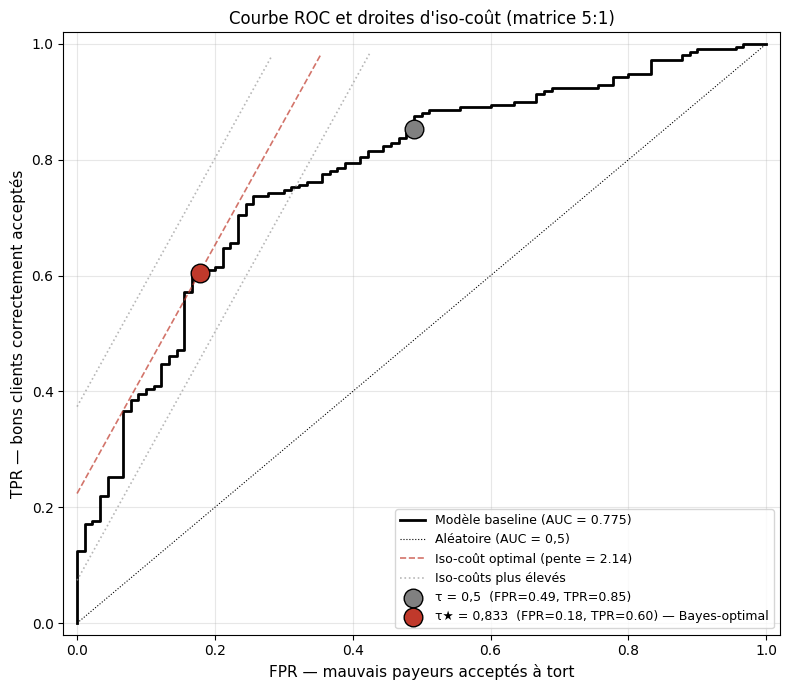

Pente des iso-coûts : 2.143
  C_FP/C_FN = 5.0
  π/(1-π) = 0.429


In [560]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# === 1. Calcul de la ROC ===
fpr, tpr, thresholds = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

# === 2. Points spécifiques (τ=0.5 et τ*=0.833) ===
def point_at_threshold(proba, y, tau):
    yhat = (proba >= tau).astype(int)
    tp = ((yhat == 1) & (y == 1)).sum()
    fn = ((yhat == 0) & (y == 1)).sum()
    fp = ((yhat == 1) & (y == 0)).sum()
    tn = ((yhat == 0) & (y == 0)).sum()
    return fp / (fp + tn), tp / (tp + fn)

y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test
fpr_05, tpr_05 = point_at_threshold(proba_test, y_test_arr, 0.5)
fpr_83, tpr_83 = point_at_threshold(proba_test, y_test_arr, 0.833)

# === 3. Pente des droites d'iso-coût ===
C_FP, C_FN = 5, 1
pi = (y_test == 0).mean()  # proportion de bad
slope = (C_FP / C_FN) * (pi / (1 - pi))

# === 4. Tracé ===
fig, ax = plt.subplots(figsize=(8, 7))

# La ROC
ax.plot(fpr, tpr, color='black', lw=2, label=f'Modèle baseline (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k:', lw=0.8, label='Aléatoire (AUC = 0,5)')

# Droites d'iso-coût (3 niveaux)
x_iso = np.linspace(0, 1, 100)
intercepts = [tpr_83 - slope * fpr_83,        # passe par le point Bayes (tangente)
              tpr_83 - slope * fpr_83 + 0.15, # iso-coût plus chère
              tpr_83 - slope * fpr_83 - 0.15] # iso-coût moins chère
labels_iso = [f'Iso-coût optimal (pente = {slope:.2f})', 'Iso-coûts plus élevés', None]
styles_iso = ['--', ':', ':']
colors_iso = ['#C0392B', '#999999', '#999999']

for inter, lbl, sty, col in zip(intercepts, labels_iso, styles_iso, colors_iso):
    y_iso = slope * x_iso + inter
    mask = (y_iso >= 0) & (y_iso <= 1)
    ax.plot(x_iso[mask], y_iso[mask], sty, color=col, lw=1.2, label=lbl, alpha=0.7)

# Points seuils
ax.scatter(fpr_05, tpr_05, s=180, color='gray', zorder=5, edgecolor='black',
           label=f'τ = 0,5  (FPR={fpr_05:.2f}, TPR={tpr_05:.2f})')
ax.scatter(fpr_83, tpr_83, s=180, color='#C0392B', zorder=5, edgecolor='black',
           label=f'τ★ = 0,833  (FPR={fpr_83:.2f}, TPR={tpr_83:.2f}) — Bayes-optimal')

ax.set_xlabel('FPR — mauvais payeurs acceptés à tort', fontsize=11)
ax.set_ylabel('TPR — bons clients correctement acceptés', fontsize=11)
ax.set_title('Courbe ROC et droites d\'iso-coût (matrice 5:1)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('roc_iso_cout.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pente des iso-coûts : {slope:.3f}")
print(f"  C_FP/C_FN = {C_FP/C_FN}")
print(f"  π/(1-π) = {pi/(1-pi):.3f}")

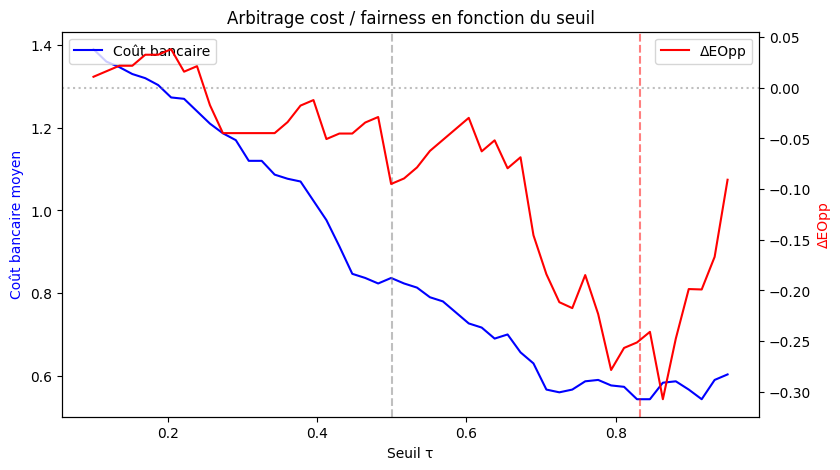

In [561]:
seuils = np.linspace(0.1, 0.95, 50)
delta_eopp = []
cout = []

for tau in seuils:
    yhat = (proba_test >= tau).astype(int)
    
    # TPR par groupe
    tpr_j = yhat[(A_test == 1) & (y_test == 1)].mean()
    tpr_a = yhat[(A_test == 0) & (y_test == 1)].mean()
    delta_eopp.append(tpr_j - tpr_a)
    
    # Coût
    fp = ((yhat == 1) & (y_test == 0)).sum()
    fn = ((yhat == 0) & (y_test == 1)).sum()
    cout.append((5*fp + fn) / len(y_test))

# Tracer en double axe
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(seuils, cout, 'b-', label='Coût bancaire')
ax2.plot(seuils, delta_eopp, 'r-', label='ΔEOpp')
ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)

ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(0.833, color='red', linestyle='--', alpha=0.5)

ax1.set_xlabel('Seuil τ')
ax1.set_ylabel('Coût bancaire moyen', color='b')
ax2.set_ylabel('ΔEOpp', color='r')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Arbitrage cost / fairness en fonction du seuil')
plt.show()

## 4. Mitigation : 

Comme expliqué plus haut , le choix le plus pertinent comme métrique cible est Eopp, qui protège l'accès des bons clients jeunes. Elle fait le plus sens notre contexte bancaire , où l'enjeu est de ne pas refuser à tort des clients solvables , tout en évitant d'aaccorder à tort des crédits à des clients risqués.



Pour rétablir Eopp , l'objectif est de faire monter le TPR des jeunes, c'est à dire faire en sorte que le modèle reconnaisse davantage les jeunes solvables.
Mais augmenter le TPR jeune peut aussi augmenter les FPR jeunes. Il faut donc qu'on soit vigilant en gardant en tête la matrice de coût du German Credit qui pénalise fortement les faux positifs.

/var/folders/ms/qzgtjj3j3mn0m5lv1hk9kcr40000gn/T/ipykernel_5926/2659163457.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


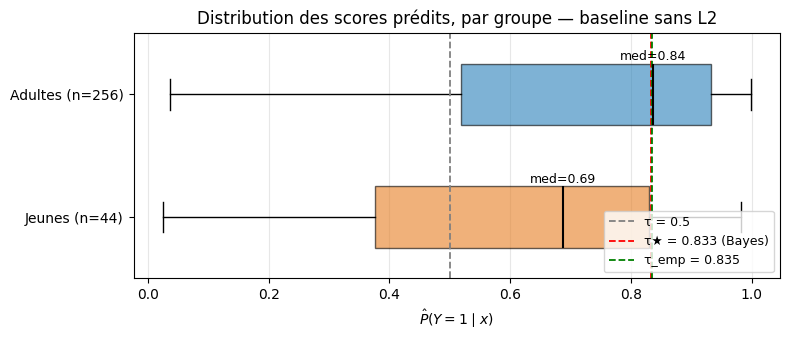

In [562]:
fig, ax = plt.subplots(figsize=(8, 3.5))                                                                                                                                                                                                               
                                                                                                                                                                                                                                                        
data = [proba_test[A_test == 1], proba_test[A_test == 0]]                                                                                                                                                                                              
labels = [f'Jeunes (n={(A_test==1).sum()})', f'Adultes (n={(A_test==0).sum()})']                                                                                                                                                                       
                                                                                                                                                                                                                                                    
bp = ax.boxplot(                                                                                                                                                                                                                                     
    data, labels=labels,                                                                                                                                                                                                                               
    patch_artist=True, vert=False, widths=0.5,                                                                                                                                                                                                       
    medianprops=dict(color='black', linewidth=1.5),                                                                                                                                                                                                  
)                                                                                                                                                                                                                                                      
for patch, c in zip(bp['boxes'], ['#E67E22', '#2980B9']):
    patch.set_facecolor(c); patch.set_alpha(0.6)                                                                                                                                                                                                       
                                                                                                                                                                                                                                                        
# Seuils de référence                                                                                                                                                                                                                                
ax.axvline(0.5,      color='gray',  ls='--', lw=1.3, label='τ = 0.5')                                                                                                                                                                                  
ax.axvline(tau_star, color='red',   ls='--', lw=1.3, label=f'τ★ = {tau_star:.3f} (Bayes)')                                                                                                                                                             
ax.axvline(tau_emp,  color='green', ls='--', lw=1.3, label=f'τ_emp = {tau_emp:.3f}')                                                                                                                                                                   
                                                                                                                                                                                                                                                        
# Médianes annotées                                                                                                                                                                                                                                    
for i, group_data in enumerate(data, start=1):                                                                                                                                                                                                         
    med = np.median(group_data)                                                                                                                                                                                                                        
    ax.text(med, i + 0.28, f'med={med:.2f}', ha='center', fontsize=9, color='black')                                                                                                                                                                   
                                                                                                                                                                                                                                                        
ax.set_xlabel(r'$\hat P(Y=1 \mid x)$')                                                                                                                                                                                                                 
ax.set_title('Distribution des scores prédits, par groupe — baseline sans L2')                                                                                                                                                                         
ax.legend(loc='lower right', fontsize=9)                                                                                                                                                                                                               
ax.grid(axis='x', alpha=0.3)                                                                                                                                                                                                                         
plt.tight_layout()                                                                                                                                                                                                                                     
plt.show()     

Cette figure met en évidence un phénomène central pour l’analyse de fairness : 

$$
\tau^\star = 0.833
$$

Le seuil bayésien optimal, n’interagit pas de la même manière avec les distributions de scores des jeunes et des adultes.

Chez les adultes, la médiane des scores prédits (\(0.84\)) est presque exactement alignée avec le seuil optimal . Le seuil se situe donc dans la région centrale de la distribution, ce qui signifie qu’une proportion importante des adultes possède naturellement des scores compatibles avec l’acceptation.

Chez les jeunes, la situation est très différente, la médiane (\(0.69\)) est nettement inférieure au seuil. Le seuil optimal se retrouve alors placé dans l’extrémité haute de la distribution des jeunes, c’est-à-dire dans une zone contenant relativement peu d’individus.

Ce résultat est particulièrement important dans le cadre de l’Equal Opportunity (\(EOpp\)). Même avant de distinguer les bons et mauvais clients, les jeunes disposent globalement de scores plus faibles. Le seuil unique agit donc de manière asymétrique :

- il coupe la distribution des adultes près de son centre,
- mais coupe la distribution des jeunes dans sa queue supérieure.

Autrement dit, le système n’applique pas réellement le même niveau d’exigence statistique aux deux groupes. À seuil identique, les jeunes doivent appartenir à une fraction beaucoup plus extrême de leur distribution pour être acceptés.

Ce décalage des distributions peut s’expliquer par plusieurs mécanismes combinés. Une partie provient probablement des différences de taux de base observées dans les données : les jeunes présentent une proportion plus faible de clients solvables, ce qui conduit naturellement le modèle à produire des scores plus faibles en moyenne.

Cependant, ce phénomène peut également être amplifié par des variables fortement corrélées à l’âge ( comme l’ancienneté bancaire, la stabilité professionnelle ou l’historique de crédit ) qui agissent comme des proxys du groupe sensible. Le modèle apprend alors non seulement les différences réelles de risque présentes dans les données, mais aussi certaines structures historiques du système de crédit, où les jeunes disposent souvent de moins d’informations financières positives pour être évalués favorablement.

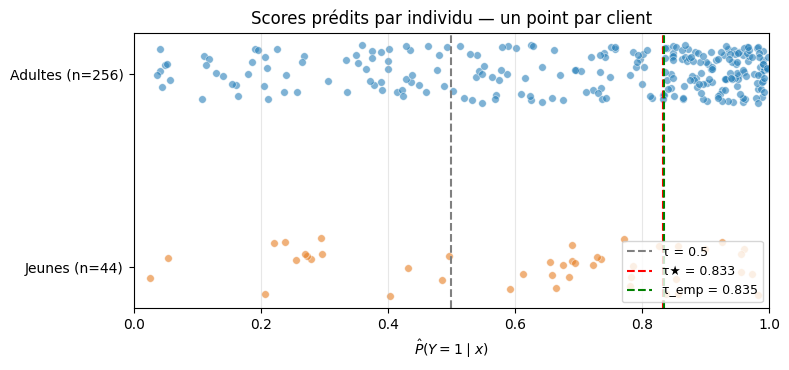

In [563]:
fig, ax = plt.subplots(figsize=(8, 3.8))                                                                                                                                                                                                               
                                                                                                                                                                                                                                                    
# Un point par individu, jitter vertical pour éviter superposition                                                                                                                                                                                     
rng = np.random.default_rng(0)                                                                                                                                                                                                                         
for i, (mask, label, color) in enumerate([                                                                                                                                                                                                             
    (A_test == 1, f'Jeunes (n={(A_test==1).sum()})',  '#E67E22'),                                                                                                                                                                                    
    (A_test == 0, f'Adultes (n={(A_test==0).sum()})', '#2980B9'),                                                                                                                                                                                      
]):                                                                                                                                                                                                                                                    
    scores = proba_test[mask]                                                                                                                                                                                                                          
    y_jitter = i + rng.uniform(-0.15, 0.15, size=len(scores))                                                                                                                                                                                          
    ax.scatter(scores, y_jitter, color=color, alpha=0.6, s=30, edgecolor='white', linewidth=0.5)                                                                                                                                                       
                                                                                                                                                                                                                                                        
ax.set_yticks([0, 1])                                                                                                                                                                                                                                  
ax.set_yticklabels([f'Jeunes (n={(A_test==1).sum()})', f'Adultes (n={(A_test==0).sum()})'])                                                                                                                                                            
                                                                                                                                                                                                                                                        
ax.axvline(0.5,      color='gray',  ls='--', lw=1.5, label='τ = 0.5')                                                                                                                                                                                  
ax.axvline(tau_star, color='red',   ls='--', lw=1.5, label=f'τ★ = {tau_star:.3f}')                                                                                                                                                                     
ax.axvline(tau_emp,  color='green', ls='--', lw=1.5, label=f'τ_emp = {tau_emp:.3f}')                                                                                                                                                                   
                                                                                                                                                                                                                                                        
ax.set_xlabel(r'$\hat P(Y=1 \mid x)$')                                                                                                                                                                                                                 
ax.set_xlim(0, 1)                                                                                                                                                                                                                                      
ax.set_title('Scores prédits par individu — un point par client')                                                                                                                                                                                      
ax.legend(loc='lower right', fontsize=9)                                                                                                                                                                                                               
ax.grid(axis='x', alpha=0.3)                                                                                                                                                                                                                           
plt.tight_layout()                                                                                                                                                                                                                                     
plt.show()                         

Cette figure individualise ce que la figure 1 montre en agrégat, et révèle l'effet "petit échantillon" sur les Jeunes.

Le modèle, n'ayant pas vu assez d'exemples, produit des scores systématiquement plus prudents (tirés vers le centre) pour ce groupe. C'est un effet de régularisation implicite lié au déséquilibre des données, le modèle "ne sait pas trancher" sur les Jeunes, donc il les classe modérément.

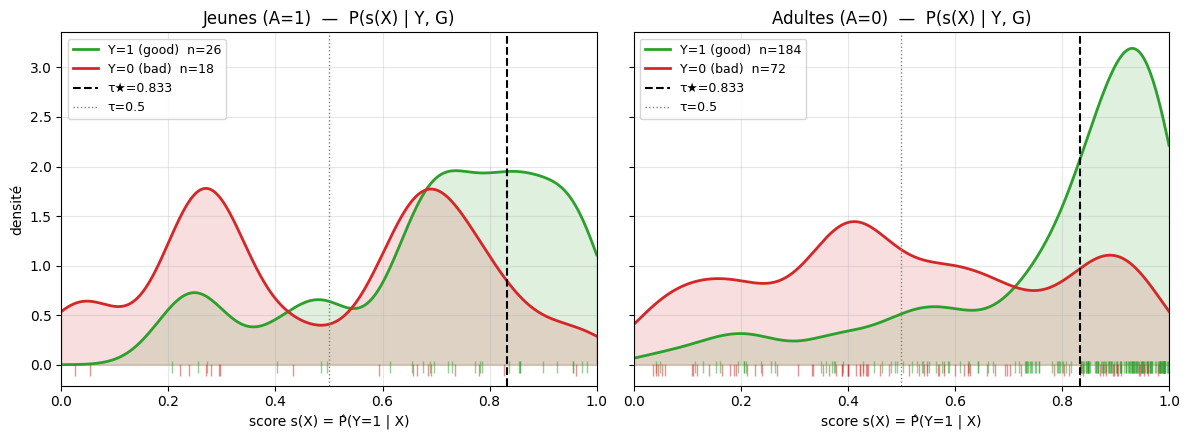

Moyennes conditionnelles E[s(X) | Y, G] :
  Jeunes (A=1)        Y=1 (good) : 0.705  (n=26)
  Jeunes (A=1)        Y=0 (bad) : 0.484  (n=18)
  Adultes (A=0)       Y=1 (good) : 0.784  (n=184)
  Adultes (A=0)       Y=0 (bad) : 0.512  (n=72)


In [564]:
A_arr = np.asarray(A_test)                                                                                              
y_arr = np.asarray(y_test)                                                                                            
p     = np.asarray(proba_test)                                                                                          
                                                                                                                    
TAU = 5/6  # 0.833

groups = {1: "Jeunes (A=1)", 0: "Adultes (A=0)"}                                                                        
colors_y = {1: "C2", 0: "C3"}  # vert = good (Y=1), rouge = bad (Y=0)
labels_y = {1: "Y=1 (good)", 0: "Y=0 (bad)"}                                                                            
                                                                                                                        
xs = np.linspace(0, 1, 400)                                                                                             
                                                                                                                        
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)                                                          

for ax, (g_val, g_name) in zip(axes, groups.items()):                                                                   
    mask_g = (A_arr == g_val)                                                                                         
    for y_val in [1, 0]:                                                                                                
        mask = mask_g & (y_arr == y_val)
        scores = p[mask]                                                                                                
        n = mask.sum()                                                                                                  
        # KDE
        kde = gaussian_kde(scores, bw_method=0.25)                                                                      
        ax.plot(xs, kde(xs), color=colors_y[y_val], lw=2,                                                               
                label=f"{labels_y[y_val]}  n={n}")                                                                      
        ax.fill_between(xs, kde(xs), alpha=0.15, color=colors_y[y_val])                                                 
        # rug                                                                                                           
        ax.plot(scores, np.full_like(scores, -0.05) + (0.03 if y_val == 1 else 0),                                    
                "|", color=colors_y[y_val], alpha=0.5, markersize=8)                                                    
    ax.axvline(TAU, color="k", ls="--", lw=1.5, label=f"τ★={TAU:.3f}")                                                  
    ax.axvline(0.5, color="gray", ls=":", lw=1, label="τ=0.5")                                                          
    ax.set_title(f"{g_name}  —  P(s(X) | Y, G)")                                                                        
    ax.set_xlabel("score s(X) = P̂(Y=1 | X)")                                                                            
    ax.set_xlim(0, 1)                                                                                                   
    ax.legend(fontsize=9, loc="upper left")                                                                             
    ax.grid(alpha=0.3)                                                                                                  
                                                                                                                    
axes[0].set_ylabel("densité")                                                                                           
plt.tight_layout()                                                                                                    
plt.show()                                                                                                              

# Diagnostics : moyennes conditionnelles                                                                                
print("Moyennes conditionnelles E[s(X) | Y, G] :")                                                                    
for g_val, g_name in groups.items():                                                                                    
    for y_val in [1, 0]:                                                                                                
        mask = (A_arr == g_val) & (y_arr == y_val)
        print(f"  {g_name:18s}  {labels_y[y_val]} : {p[mask].mean():.3f}  (n={mask.sum()})")  

Cette figure 3 évalue le pouvoir discriminant du score :

$$
s(X)=P(Y=1 \mid X),
$$

c’est-à-dire sa capacité à séparer les bons clients ($Y=1$) des mauvais ($Y=0$) dans chaque groupe.


- Chez les adultes :  
</br>
Les distributions restent relativement bien séparées. Les bons clients ($Y=1$) sont principalement concentrés sur des scores élevés, proches de $1$, tandis que les mauvais clients ($Y=0$) sont davantage concentrés autour de scores intermédiaires. Le score conserve donc un pouvoir discriminant satisfaisant.

- Chez les jeunes :  
</br>
Les distributions sont beaucoup plus diffuses et fortement chevauchées. La distribution des mauvais clients ($Y=0$) présente notamment une seconde zone de forte densité autour de $0.7$, qui se superpose largement à celle des bons clients ($Y=1$). Dans l’intervalle $[0.5 ; 0.85]$, les deux classes reçoivent ainsi des scores très similaires, ce qui réduit fortement la capacité du score à distinguer correctement les profils.



> Cette absence de séparation claire révèle une perte de pouvoir discriminant du modèle chez les jeunes. Dans la zone \([0.5 ; 0.85]\), les scores ne permettent plus de distinguer correctement les bons et mauvais profils, ce qui rend toute correction de l’Equal Opportunity (\(EOpp\)) particulièrement difficile. Abaisser le seuil pour augmenter le \(TPR\) des jeunes conduit alors inévitablement à accepter simultanément davantage de faux positifs, car les deux distributions sont fortement entremêlées. La figure 5 permettra précisément de quantifier ce compromis entre amélioration de l’EOpp et augmentation du risque.

Jeunes (A=1) : AUC = 0.733  IC95% [0.568, 0.875]  n=44
Adultes (A=0): AUC = 0.778  IC95% [0.713, 0.838]  n=256
|ΔAUC| = 0.045


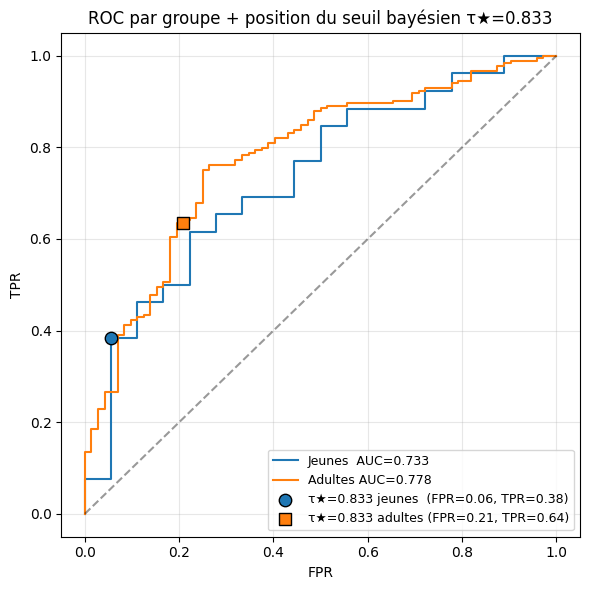


ΔTPR(τ★) = TPR_jeunes - TPR_adultes = -0.251  → |ΔEOpp|
ΔFPR(τ★) = FPR_jeunes - FPR_adultes = -0.153


In [565]:
A_arr = np.asarray(A_test)                                                                                              
y_arr = np.asarray(y_test)                                                                                              
mask_young = (A_arr == 1)                                                                                               
mask_old   = (A_arr == 0)                                                                                               

TAU = 5/6  # 0.833                                                                                                      
                
auc_young = roc_auc_score(y_arr[mask_young], proba_test[mask_young])                                                    
auc_old   = roc_auc_score(y_arr[mask_old],   proba_test[mask_old])
                                                                                                                        
def bootstrap_auc(y, p, n_boot=1000, seed=42):                                                                          
    rng = np.random.default_rng(seed)
    n = len(y)                                                                                                          
    samples = []
    for _ in range(n_boot):                                                                                             
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) == 2:                                                                                 
            samples.append(roc_auc_score(y[idx], p[idx]))                                                               
    return np.percentile(samples, [2.5, 50, 97.5])
                                                                                                                        
lo_y, _, hi_y = bootstrap_auc(y_arr[mask_young], proba_test[mask_young])                                                
lo_o, _, hi_o = bootstrap_auc(y_arr[mask_old],   proba_test[mask_old])                                                  
                                                                                                                        
print(f"Jeunes (A=1) : AUC = {auc_young:.3f}  IC95% [{lo_y:.3f}, {hi_y:.3f}]  n={mask_young.sum()}")                    
print(f"Adultes (A=0): AUC = {auc_old:.3f}  IC95% [{lo_o:.3f}, {hi_o:.3f}]  n={mask_old.sum()}")                        
print(f"|ΔAUC| = {abs(auc_young - auc_old):.3f}")                                                                       
                                                                                                                        
fpr_y, tpr_y, thr_y = roc_curve(y_arr[mask_young], proba_test[mask_young])                                              
fpr_o, tpr_o, thr_o = roc_curve(y_arr[mask_old],   proba_test[mask_old])                                                
                                                                                                                        
def point_at_tau(y, p, tau):                                                                                            
    yhat = (p >= tau).astype(int)
    tp = ((yhat == 1) & (y == 1)).sum()                                                                                 
    fn = ((yhat == 0) & (y == 1)).sum()
    fp = ((yhat == 1) & (y == 0)).sum()                                                                                 
    tn = ((yhat == 0) & (y == 0)).sum()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0                                                                          
    fpr = fp / (fp + tn) if (fp + tn) else 0.0                                                                          
    return fpr, tpr                                                                                                     
                                                                                                                        
fpr_yt, tpr_yt = point_at_tau(y_arr[mask_young], proba_test[mask_young], TAU)                                           
fpr_ot, tpr_ot = point_at_tau(y_arr[mask_old],   proba_test[mask_old],   TAU)
                                                                                                                        
plt.figure(figsize=(6, 6))                                                                                              
plt.plot(fpr_y, tpr_y, label=f"Jeunes  AUC={auc_young:.3f}", color="C0")
plt.plot(fpr_o, tpr_o, label=f"Adultes AUC={auc_old:.3f}",   color="C1")                                                
plt.scatter([fpr_yt], [tpr_yt], color="C0", s=80, zorder=5, edgecolor="k",                                              
            label=f"τ★=0.833 jeunes  (FPR={fpr_yt:.2f}, TPR={tpr_yt:.2f})")                                             
plt.scatter([fpr_ot], [tpr_ot], color="C1", s=80, zorder=5, edgecolor="k", marker="s",                                  
            label=f"τ★=0.833 adultes (FPR={fpr_ot:.2f}, TPR={tpr_ot:.2f})")                                             
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)                                                                              
plt.xlabel("FPR"); plt.ylabel("TPR")                                                                                    
plt.title("ROC par groupe + position du seuil bayésien τ★=0.833")                                                       
plt.legend(loc="lower right", fontsize=9)                                                                               
plt.grid(alpha=0.3)                                                                                                     
plt.tight_layout()                                                                                                      
plt.show()                                                                                                              
                
print(f"\nΔTPR(τ★) = TPR_jeunes - TPR_adultes = {tpr_yt - tpr_ot:+.3f}  → |ΔEOpp|")                                     
print(f"ΔFPR(τ★) = FPR_jeunes - FPR_adultes = {fpr_yt - fpr_ot:+.3f}")

Figure 4, courbe ROC par groupe.

> Bien que les performances globales de ranking restent relativement correctes, comme le suggère la proximité des courbes ROC entre groupes, l’analyse des densités révèle un phénomène plus local : chez les jeunes, les distributions de scores des classes \(Y=0\) et \(Y=1\) se chevauchent fortement dans la région du seuil de décision. Le modèle conserve donc une capacité globale d'ordonnancement des individus, mais perd en pouvoir discriminant local autour des zones critiques pour la décision de crédit.

In [566]:
A_arr = np.asarray(A_test)                                                                                                               
y_arr = np.asarray(y_test)                                                                                                             
p     = np.asarray(proba_test)                                                                                                           

mask_young = (A_arr == 1)                                                                                                                
mask_old   = (A_arr == 0)                                                                                                              

def confusion_at(tau, mask):                                                                                                             
    yhat = (p[mask] >= tau).astype(int)
    y    = y_arr[mask]                                                                                                                   
    TP = int(((yhat == 1) & (y == 1)).sum())                                                                                           
    FP = int(((yhat == 1) & (y == 0)).sum())                                                                                             
    FN = int(((yhat == 0) & (y == 1)).sum())
    TN = int(((yhat == 0) & (y == 0)).sum())                                                                                             
    P, N = (y == 1).sum(), (y == 0).sum()                                                                                                
    return {"TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "TPR": TP/P if P else 0,                                                                                                     
            "FPR": FP/N if N else 0,                                                                                                   
            "PPV": TP/(TP+FP) if (TP+FP) else 0,                                                                                         
            "coût": 5*FP + FN}                                                                                                           

def table_at(tau):                                                                                                                       
    df = pd.DataFrame(                                                                                                                 
        [confusion_at(tau, mask_young), confusion_at(tau, mask_old)],                                                                    
        index=pd.Index(["Jeunes", "Adultes"], name="Groupe"),
    )                                                                                                                                    
    return df.style.format({"TPR": "{:.3f}", "FPR": "{:.3f}", "PPV": "{:.3f}"}).set_caption(f"Matrice de confusion — τ = {tau:.3f}")                                                                 
                                                                                                                                        
display(table_at(5/6))                                                                                                                   
display(table_at(0.6))                                                                                                                   
                        

,TP,FP,FN,TN,TPR,FPR,PPV,coût
Groupe,,,,,,,,
Jeunes,10,1,16,17,0.385,0.056,0.909,21
Adultes,117,15,67,57,0.636,0.208,0.886,142


,TP,FP,FN,TN,TPR,FPR,PPV,coût
Groupe,,,,,,,,
Jeunes,20,8,6,10,0.769,0.444,0.714,46
Adultes,147,28,37,44,0.799,0.389,0.840,177


<i>  Le seuil 0.6 ici est prit à titre d'exemple pour mettre en avant le coût du compromis </i> 

a. Réduction de l’écart EOpp au prix d’une explosion du risque : 


Ce tableau met en avant l’impact concret du chevauchement des distributions observé dans la Figure 1. </br>
Lorsque les scores des bons et mauvais jeunes clients deviennent trop similaires, améliorer l’Equal Opportunity (\(EOpp\)) nécessite mécaniquement d’accepter davantage de faux positifs.

Avec le seuil bayésien optimal :

$$
\tau^\star = 0.833
$$

le système minimise le coût bancaire, mais produit un fort déséquilibre entre groupes avec un écart de **25.1 points**.

Le modèle rejette donc une proportion beaucoup plus importante de bons jeunes clients.

Lorsque le seuil est abaissé à :

$$
\tau = 0.6
$$

le \(TPR\) des jeunes augmente fortement :

$$
0.385 \rightarrow 0.769
$$

et devient proche de celui des adultes :

$$
TPR_{adultes}=0.799
$$

Le critère EOpp est alors presque satisfait.

Cependant, cette amélioration s’accompagne d’une forte hausse du risque :

- $FPR_{jeunes} : 0.056 \rightarrow 0.444$
- Coût total : $163 \rightarrow 223$ $(+37\%)$

Cette dégradation provient directement du chevauchement des distributions. Dans la zone \([0.5 ; 0.85]\), le modèle ne distingue plus correctement les bons et mauvais jeunes clients.

b. Pourquoi le chevauchement des distributions empêche le break-even

Le gain obtenu en vrais positifs reste alors faible par rapport à l’augmentation des faux positifs :

$$
\frac{\Delta TP}{\Delta FP}
=
\frac{20-10}{8-1}
=
1.43
$$

Autrement dit, chaque faux positif supplémentaire permet de récupérer seulement \(1.43\) vrais positifs.

Or, dans le cadre bancaire étudié ici, un faux positif coûte cinq fois plus cher qu’un faux négatif. Pour que l’abaissement du seuil reste économiquement neutre (*break-even*), il faudrait donc que chaque faux positif supplémentaire permette de récupérer au moins \(5\) vrais positifs :

$$
\frac{\Delta TP}{\Delta FP} \geq 5
$$

Ce n’est clairement pas le cas ici :

$$
1.43 \ll 5
$$

L’amélioration de l’Equal Opportunity devient alors économiquement inefficace , le système accepte beaucoup trop de profils risqués par rapport au nombre de bons clients réellement récupérés.

Focus sur les jeunes :

In [567]:
ry1 = confusion_at(5/6, mask_young) 
ry2 = confusion_at(0.6, mask_young)
                                                                                                                                        
effet = pd.DataFrame({
    "τ★=0.833": [ry1["TP"], ry1["FP"], ry1["coût"]],                                                                                     
    "τ=0.6":    [ry2["TP"], ry2["FP"], ry2["coût"]],                                                                                     
    "Δ":        [ry2["TP"]-ry1["TP"], ry2["FP"]-ry1["FP"], ry2["coût"]-ry1["coût"]],                                                     
}, index=["TP (bons récupérés)", "FP (mauvais acceptés)", "Coût (5·FP+FN)"])                                                             
                                                                                                                                        
ratio = (ry2["TP"]-ry1["TP"]) / max(1, ry2["FP"]-ry1["FP"])                                                                              
                                                                                                                                        
display(effet)                                                                                                                                       


,τ★=0.833,τ=0.6,Δ
TP (bons récupérés),10,20,10
FP (mauvais acceptés),1,8,7
Coût (5·FP+FN),21,46,25


Les analyses précédentes mettent en évidence deux problèmes distincts dans le comportement du modèle.

Le premier concerne le fort chevauchement des distributions de scores chez les jeunes. Les profils \(Y=1\) et \(Y=0\) y sont beaucoup moins séparés que chez les adultes, ce qui révèle une perte de pouvoir discriminant du modèle pour ce groupe. Dans cette situation, améliorer l’Equal Opportunity (\(EOpp\)) devient difficile, car toute augmentation du \(TPR\) entraîne simultanément une hausse importante du \(FPR\).

Le second problème concerne le décalage global des distributions de scores entre groupes. Le seuil bayésien optimal \(\tau^\star\) n’occupe pas la même position dans les distributions des jeunes et des adultes : il se situe près du centre de la distribution adulte, mais dans la queue supérieure de la distribution des jeunes. Le même seuil impose donc implicitement des niveaux d’exigence différents selon les groupes.

Ces deux diagnostics motivent naturellement deux axes de mitigation complémentaires :

- un axe de **post-processing**, qui agit sur les seuils de décision afin de rééquilibrer les métriques de fairness tout en contrôlant le coût bancaire acceptable ;

- un axe de **pre/in-processing**, qui cherche à améliorer directement la séparabilité des distributions de scores afin de réduire le chevauchement entre bons et mauvais profils chez les jeunes.

## Axe B - Pre / In-processing : Amélioration du pouvoir discriminant chez les jeunes

Le recours au reweighting est motivé par la sous-représentation des individus jeunes dans les données d’apprentissage. Cette méthode ne cible pas directement le chevauchement local observé entre les distributions de scores des jeunes $Y=1$ et $Y=0$ autour du seuil opérationnel $\tau^\star$. En revanche, elle repose sur l’hypothèse qu’en augmentant le poids des observations jeunes durant l’apprentissage, le modèle pourra mieux apprendre leur structure statistique propre et améliorer indirectement leur séparabilité.

L’objectif est donc de tester si une partie des écarts de fairness observés provient d’un apprentissage dominé par le groupe adulte majoritaire. Si tel est le cas, renforcer l’influence des jeunes dans la fonction de coût pourrait conduire à une meilleure discrimination des profils jeunes $Y=1$ et $Y=0$, notamment dans les régions critiques de décision.


a. Step 1 - le choix des poids ? 

Afin de réduire l’effet de sous-représentation des jeunes profils solvables dans l’apprentissage, une stratégie de reweighting inspirée de Kamiran-Calders est appliquée. L’idée consiste à augmenter l’influence des individus jeunes ayant $Y=1$ dans la fonction de coût du modèle.

Plus précisément, les poids sont réalloués uniquement à l’intérieur de la classe positive ($Y=1$). Chaque sous-groupe $(A,Y=1)$ reçoit un poids inversement proportionnel à sa fréquence dans les données d’apprentissage :

$$
w(A=a,Y=1)
=
\frac{n_{Y=1}}{2\,n_{A=a,Y=1}}
$$

où $n_{Y=1}$ désigne le nombre total d’observations positives et $n_{A=a,Y=1}$ le nombre d’observations positives du groupe considéré.

Ainsi, les jeunes solvables, plus rares dans les données, obtiennent un poids plus élevé que les adultes solvables. L’objectif est d’inciter le modèle à mieux apprendre les caractéristiques discriminantes propres aux jeunes profils $Y=1$, afin d’améliorer indirectement leur séparabilité vis-à-vis des profils $Y=0$.

In [582]:
A_train_arr = np.asarray(A_train)                                                                                                        
y_train_arr = np.asarray(y_train)                                                                                                        
                                                                                                                                        
sample_weight = np.ones(len(y_train_arr))                                                                                                
mask_pos = (y_train_arr == 1)                                                                                                          
n_pos = mask_pos.sum()                                                                                                                 
                                                                                                                                        
for a_val in [0, 1]:
    m = mask_pos & (A_train_arr == a_val)                                                                                                
    sample_weight[m] = n_pos / (2 * m.sum())                                                                                           
                                                                                                                                        
                                                                                                                                        
for a_val, name in [(1, "Jeunes"), (0, "Adultes")]:                                                                                      
    mp = mask_pos & (A_train_arr == a_val)                                                                                             
    print(f"(A={a_val} {name:8s}, Y=1) : w = {sample_weight[mp][0]:.3f}   n = {mp.sum()}")                                               
                                                                                                

(A=1 Jeunes  , Y=1) : w = 3.952   n = 62
(A=0 Adultes , Y=1) : w = 0.572   n = 428


In [588]:
# Modèle reweighted                                                                                                               
reweighted = Pipeline([                                                                                                                
    ("preproc", preprocessor),
    ("clf", LogisticRegression(class_weight=None, max_iter=1000,
                                random_state=RANDOM_STATE)),                                                                              
])
reweighted.fit(X_train, y_train, clf__sample_weight=sample_weight)                                                                       
proba_test_rw = reweighted.predict_proba(X_test)[:, 1]       

In [589]:
TAU = 5/6
A_arr = np.asarray(A_test); y_arr = np.asarray(y_test)                                                                                   

def metrics_block(p, label):                                                                                                             
    rows = []                                                                                                                          
    for a_val, gname in [(1, "Jeunes"), (0, "Adultes")]:                                                                                 
        m = (A_arr == a_val)                                                                                                           
        yhat = (p[m] >= TAU).astype(int); y = y_arr[m]
        TP=((yhat==1)&(y==1)).sum(); FP=((yhat==1)&(y==0)).sum()                                                                         
        FN=((yhat==0)&(y==1)).sum()                                                                                                      
        P,N=(y==1).sum(),(y==0).sum()                                                                                                    
        rows.append({"Modèle":label, "Groupe":gname,                                                                                     
                    "TPR": TP/P if P else 0, "FPR": FP/N if N else 0,                                                                   
                    "PPV": TP/(TP+FP) if (TP+FP) else 0,
                    "coût": int(5*FP+FN)})                                                                                              
    return rows                                                                                                                        
                                                                                                                                        
df = pd.DataFrame(metrics_block(proba_test,    "Naturel")                                                                                
                + metrics_block(proba_test_rw, "Reweighted")
                ).set_index(["Modèle", "Groupe"])                                                                                        
                                                                                                                                        
# |ΔEOpp| par modèle                                                                                                                     
eopp = df["TPR"].unstack("Groupe").assign(
    **{"|ΔEOpp|": lambda d: (d["Jeunes"] - d["Adultes"]).abs()}                                                                          
)[["|ΔEOpp|"]]                                                                                                                           

display(df.style.format({"TPR":"{:.3f}", "FPR":"{:.3f}", "PPV":"{:.3f}"})                                                                
                .set_caption(f"Métriques par groupe à τ★ = {TAU:.3f}"))                                                                
                                                                                                                                        
display(eopp.style.format("{:.3f}")                                                                                                    
                .set_caption("|ΔEOpp| = |TPR Jeunes − TPR Adultes|"))                      

Groupe,|ΔEOpp|
Modèle,
Naturel,0.251
Reweighted,0.016


Le reweighting réduit fortement l’écart d’Equal Opportunity entre groupes :

$$
|\Delta EOpp| : 0.251 \rightarrow 0.016
$$

Les taux de vrais positifs deviennent ainsi presque identiques entre jeunes et adultes, ce qui constitue une amélioration substantielle du point de vue fairness.

Cette amélioration est obtenue avec une augmentation relativement modérée du coût total du système :

$$
163 \rightarrow 188 \quad (+15\%)
$$

ce qui suggère qu’un rééquilibrage significatif des performances entre groupes peut être atteint sans dégradation excessive de l’objectif économique global.

L’analyse détaillée montre cependant que cette réduction du gap de fairness provient d’un double mouvement. Chez les jeunes, le taux de vrais positifs augmente :

$$
0.385 \rightarrow 0.500
$$

mais cette amélioration s’accompagne également d’une forte hausse du taux de faux positifs :

$$
0.056 \rightarrow 0.278
$$

Le modèle accepte donc davantage de jeunes solvables, mais également davantage de jeunes en défaut. Cette dynamique se traduit par une baisse du pouvoir prédictif positif chez les jeunes :

$$
0.909 \rightarrow 0.722
$$

et par une augmentation du coût associé à ce groupe :

$$
21 \rightarrow 38
$$

Parallèlement, les performances diminuent chez les adultes :

$$
TPR : 0.636 \rightarrow 0.484
$$

Le rééquilibrage de fairness ne provient donc pas uniquement d’une amélioration des jeunes, mais également d’une baisse du taux de détection des profils solvables adultes. Le modèle devient ainsi moins spécialisé pour le groupe majoritaire au profit d’un comportement plus homogène entre groupes.

Ces résultats suggèrent finalement que le reweighting agit principalement comme une translation globale des scores des jeunes, sans amélioration réelle de leur séparabilité interne.

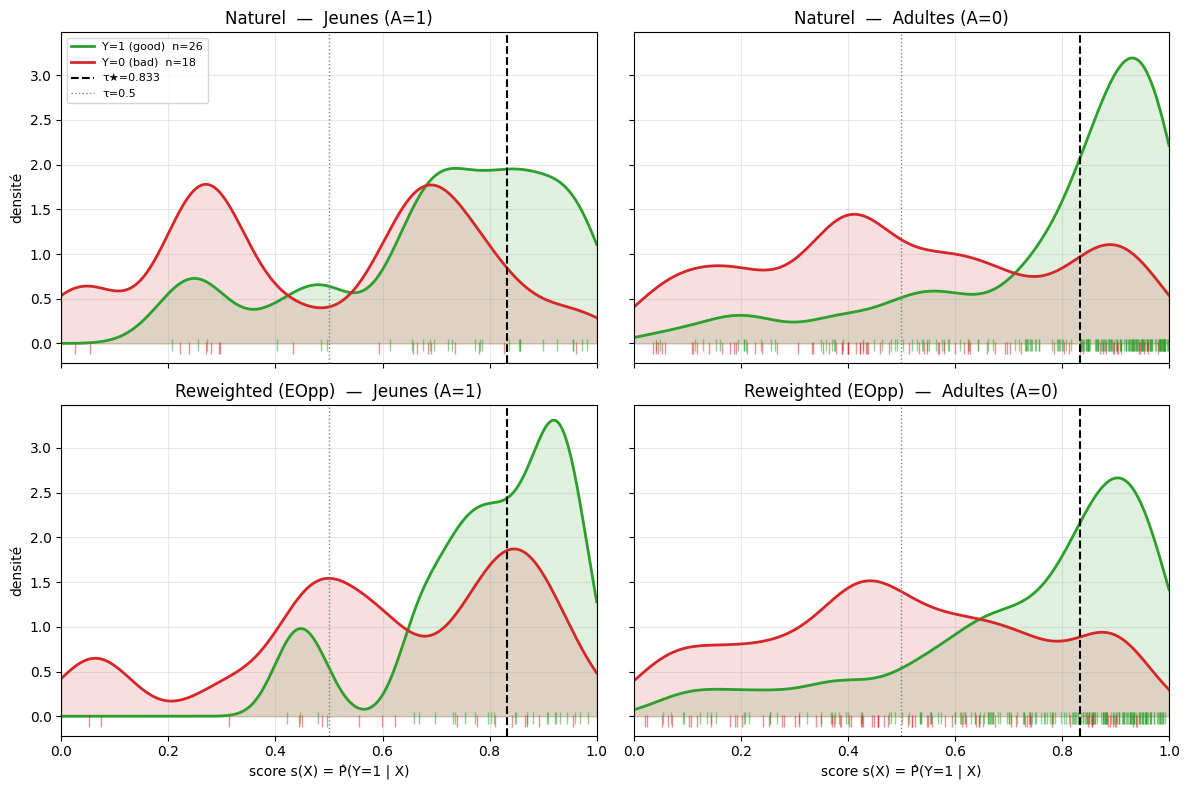

E[s(X) | Y, G] :
                                Naturel   Reweighted         Δ
  Jeunes (A=1)       Y=1 (good)      0.705        0.795    +0.090  (n=26)
  Jeunes (A=1)       Y=0 (bad)      0.484        0.603    +0.119  (n=18)
  Adultes (A=0)      Y=1 (good)      0.784        0.737    -0.047  (n=184)
  Adultes (A=0)      Y=0 (bad)      0.512        0.498    -0.014  (n=72)


In [569]:
A_arr = np.asarray(A_test)                                                                                                               
y_arr = np.asarray(y_test)
                                                                                                                                        
TAU = 5/6
groups = {1: "Jeunes (A=1)", 0: "Adultes (A=0)"}                                                                                         
colors_y = {1: "C2", 0: "C3"}
labels_y = {1: "Y=1 (good)", 0: "Y=0 (bad)"}                                                                                             
xs = np.linspace(0, 1, 400)
                                                                                                                                        
models = [("Naturel", proba_test), ("Reweighted (EOpp)", proba_test_rw)]                                                                 
                                                                                                                                        
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)                                                                
                
for row, (mname, p) in enumerate(models):                                                                                                
    for col, (g_val, g_name) in enumerate(groups.items()):
        ax = axes[row, col]
        mask_g = (A_arr == g_val)                                                                                                        
        for y_val in [1, 0]:
            mask = mask_g & (y_arr == y_val)                                                                                             
            scores = p[mask]
            kde = gaussian_kde(scores, bw_method=0.25)                                                                                   
            ax.plot(xs, kde(xs), color=colors_y[y_val], lw=2,
                    label=f"{labels_y[y_val]}  n={mask.sum()}")                                                                          
            ax.fill_between(xs, kde(xs), alpha=0.15, color=colors_y[y_val])
            ax.plot(scores, np.full_like(scores, -0.05) + (0.03 if y_val == 1 else 0),                                                   
                    "|", color=colors_y[y_val], alpha=0.5, markersize=8)
        ax.axvline(TAU, color="k", ls="--", lw=1.5, label=f"τ★={TAU:.3f}")                                                               
        ax.axvline(0.5, color="gray", ls=":", lw=1, label="τ=0.5")                                                                       
        ax.set_title(f"{mname}  —  {g_name}")                                                                                            
        ax.set_xlim(0, 1)                                                                                                                
        ax.grid(alpha=0.3)
        if row == 1:                                                                                                                     
            ax.set_xlabel("score s(X) = P̂(Y=1 | X)")                                                                                     
        if col == 0:
            ax.set_ylabel("densité")                                                                                                     
        if row == 0 and col == 0:                                                                                                        
            ax.legend(fontsize=8, loc="upper left")
                                                                                                                                        
plt.tight_layout()
plt.show()
                                                                                                                                        
# Diagnostics : moyennes conditionnelles E[s(X) | Y, G] pour les deux modèles                                                            
print("E[s(X) | Y, G] :")                                                                                                                
print(f"{'':28s} {'Naturel':>10s}   {'Reweighted':>10s}   {'Δ':>7s}")                                                                    
for g_val, g_name in groups.items():                                                                                                     
    for y_val in [1, 0]:
        mask = (A_arr == g_val) & (y_arr == y_val)                                                                                       
        m_nat = proba_test[mask].mean()
        m_rw  = proba_test_rw[mask].mean()                                                                                               
        print(f"  {g_name:18s} {labels_y[y_val]:8s} "
            f"{m_nat:10.3f}   {m_rw:10.3f}   {m_rw - m_nat:+7.3f}  (n={mask.sum()})")                                                  
                                                                                        

Le reweighting permet d’obtenir une amélioration importante des métriques de fairness. L’écart d’Equal Opportunity devient presque nul, tandis que l’augmentation du coût total reste relativement modérée. Dans le cadre expérimental considéré, cette approche apparaît donc comme une stratégie de mitigation efficace pour rééquilibrer les performances entre jeunes et adultes.

Cependant, l’analyse détaillée des métriques montre que cette amélioration doit être interprétée avec prudence. Le gain de fairness ne provient pas d’une meilleure capacité du modèle à distinguer les jeunes profils solvables des profils risqués. Le reweighting augmente simultanément le taux de vrais positifs et le taux de faux positifs chez les jeunes. Le modèle accorde donc davantage de crédits aux jeunes solvables, mais également à davantage de jeunes en défaut. En parallèle, les performances diminuent chez les adultes. Le rapprochement des métriques de fairness résulte ainsi principalement d’un déplacement global des décisions entre groupes plutôt que d’une amélioration réelle du pouvoir discriminant du modèle chez les jeunes.

Cette observation soulève une première limite importante concernant l’interprétation opérationnelle du résultat obtenu. L’augmentation du taux de faux positifs chez les jeunes signifie qu’un plus grand nombre de profils risqués se voient accorder un crédit. Or, dans un contexte bancaire réel, ces erreurs peuvent produire des effets dynamiques absents de l’évaluation statique réalisée ici. Une hausse durable des défauts chez les jeunes pourrait notamment alimenter des mécanismes de feedback loop explicitées plus haut, pour lequel il nous est difficile de quantifier les conséquences futures.

Une seconde limite concerne la fonction de coût utilisée dans l’expérience. Le protocole repose sur une hypothèse simplificatrice où chaque faux positif possède le même coût économique, indépendamment du montant du crédit accordé ou du niveau réel d’exposition financière. En pratique, le coût d’un défaut dépend fortement des caractéristiques du prêt, des garanties associées ou encore du profil de risque du client. Un faux positif sur un faible crédit à la consommation n’a pas les mêmes conséquences qu’un défaut sur un prêt important, cette différence est essentielle puisqu'elle caractèrise la différence de la nature des prêts initialement demandées. Le compromis fairness/coût observé ici reste donc partiellement dépendant de cette modélisation simplifiée du risque bancaire.


In [570]:
TAU = 5/6                                                                                                                                
A_arr = np.asarray(A_test)                                                                                                               
y_arr = np.asarray(y_test)                                                                                                               
                
def cost_block(p, tau):                                                                                                                  
    out = {}    
    for a_val, gname in [(1, "Jeunes"), (0, "Adultes")]:                                                                                 
        m = (A_arr == a_val)                                                                                                             
        yhat = (p[m] >= tau).astype(int); y = y_arr[m]
        FP = int(((yhat==1)&(y==0)).sum())                                                                                               
        FN = int(((yhat==0)&(y==1)).sum())                                                                                               
        out[gname] = {"FP": FP, "FN": FN, "Coût (5·FP+FN)": 5*FP + FN}                                                                   
    # total                                                                                                                              
    yhat_t = (p >= tau).astype(int)
    FP_t = int(((yhat_t==1)&(y_arr==0)).sum())                                                                                           
    FN_t = int(((yhat_t==0)&(y_arr==1)).sum())                                                                                           
    out["Total"] = {"FP": FP_t, "FN": FN_t, "Coût (5·FP+FN)": 5*FP_t + FN_t}                                                             
    return out                                                                                                                           
                                                                                                                                        
c_nat = cost_block(proba_test,    TAU)                                                                                                   
c_rw  = cost_block(proba_test_rw, TAU)
                                                                                                                                        
df = pd.DataFrame({                                                                                                                      
    ("Naturel",    "FP"):   {g: c_nat[g]["FP"] for g in c_nat},
    ("Naturel",    "FN"):   {g: c_nat[g]["FN"] for g in c_nat},                                                                          
    ("Naturel",    "Coût"): {g: c_nat[g]["Coût (5·FP+FN)"] for g in c_nat},                                                              
    ("Reweighted", "FP"):   {g: c_rw[g]["FP"] for g in c_rw},                                                                            
    ("Reweighted", "FN"):   {g: c_rw[g]["FN"] for g in c_rw},                                                                            
    ("Reweighted", "Coût"): {g: c_rw[g]["Coût (5·FP+FN)"] for g in c_rw},                                                                
    ("Δ",          "Coût"): {g: c_rw[g]["Coût (5·FP+FN)"] - c_nat[g]["Coût (5·FP+FN)"] for g in c_rw},                                   
})                                                                                                                                       
df.columns = pd.MultiIndex.from_tuples(df.columns)
                                                                                                                                        
display(df.style.set_caption(f"Coût (matrice 5:1) avant / après reweighting — τ★ = {TAU:.3f}"))  

Le recours à XGBoost vise à tester si les difficultés du modèle à discriminer les jeunes profils solvables et non solvables proviennent des limites structurelles de la régression logistique. En effet, la régression logistique repose sur une combinaison essentiellement linéaire des variables explicatives et peut ne pas capturer certaines interactions ou relations non linéaires spécifiques au groupe jeune.

XGBoost est donc utilisé comme modèle plus flexible afin d’évaluer si une modélisation non linéaire permet d’améliorer la séparation entre jeunes \(Y=1\) et \(Y=0\), en particulier dans la zone critique autour du seuil opérationnel \(\tau^\star\).

L’objectif est de déterminer si le fort chevauchement observé chez les jeunes provient principalement d’une limite du modèle utilisé ou d’un manque d’information discriminante dans les variables disponibles.

In [ ]:
                                                                                                               
                                                                                                                                        
xgb = Pipeline([
    ("preproc", preprocessor),                                                                                                           
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,                                                                               
        subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, eval_metric="logloss",                                                                                           
        random_state=RANDOM_STATE, n_jobs=-1,
    )),                                                                                                                                  
])              
xgb.fit(X_train, y_train)                                                                                                                
proba_test_xgb = xgb.predict_proba(X_test)[:, 1]
                                                                                                                                        
# ============================================================
# Comparaison AUC + fairness à τ★ : Naturel vs XGBoost                                                                                   
# ============================================================                                                                           
TAU = 5/6
A_arr = np.asarray(A_test); y_arr = np.asarray(y_test)                                                                                   
mask_y = (A_arr == 1); mask_a = (A_arr == 0)                                                                                             
                                                                                                                                        
def summary(p, label):                                                                                                                   
    auc_g = roc_auc_score(y_arr, p)                                                                                                      
    auc_y = roc_auc_score(y_arr[mask_y], p[mask_y])                                                                                      
    auc_a = roc_auc_score(y_arr[mask_a], p[mask_a])
    yhat = (p >= TAU).astype(int)                                                                                                        
    rows = {}   
    for a_val, gname in [(1,"Jeunes"),(0,"Adultes")]:                                                                                    
        m = (A_arr==a_val); y=y_arr[m]; h=yhat[m]                                                                                        
        TP=((h==1)&(y==1)).sum(); FP=((h==1)&(y==0)).sum()                                                                               
        FN=((h==0)&(y==1)).sum()                                                                                                         
        rows[gname]={"TPR":TP/max(1,(y==1).sum()),                                                                                       
                    "FPR":FP/max(1,(y==0).sum()),                                                                                       
                    "PPV":TP/max(1,(TP+FP)),                                                                                            
                    "Coût":int(5*FP+FN)}
    return {                                                                                                                             
        "AUC global": auc_g, "AUC Jeunes": auc_y, "AUC Adultes": auc_a,
        "TPR Jeunes": rows["Jeunes"]["TPR"], "TPR Adultes": rows["Adultes"]["TPR"],                                                      
        "|ΔEOpp|": abs(rows["Jeunes"]["TPR"]-rows["Adultes"]["TPR"]),                                                                    
        "|ΔPP|":   abs(rows["Jeunes"]["PPV"]-rows["Adultes"]["PPV"]),                                                                    
        "Coût Jeunes":   rows["Jeunes"]["Coût"],                                                                                         
        "Coût Adultes":  rows["Adultes"]["Coût"],                                                                                        
        "Coût total":    rows["Jeunes"]["Coût"] + rows["Adultes"]["Coût"],                                                               
    }                                                                                                                                    
                                                                                                                                        
df = pd.DataFrame({                                                                                                                      
    "Naturel (LogReg)": summary(proba_test,     "Naturel"),
    "XGBoost":          summary(proba_test_xgb, "XGBoost"),                                                                              
})
df["Δ"] = df["XGBoost"] - df["Naturel (LogReg)"]                                                                                         
                                                                                                                                        
display(df.style.format("{:.3f}", subset=pd.IndexSlice[                                                                                  
            ["AUC global","AUC Jeunes","AUC Adultes",                                                                                    
            "TPR Jeunes","TPR Adultes","|ΔEOpp|","|ΔPP|"], :])                                                                          
            .format("{:.0f}", subset=pd.IndexSlice[                                                                                    
                ["Coût Jeunes","Coût Adultes","Coût total"], :])                                                                       
            .set_caption(f"Naturel vs XGBoost — τ★ = {TAU:.3f}"))      

,Naturel (LogReg),XGBoost,Δ
AUC global,0.775,0.777,0.003
AUC Jeunes,0.733,0.694,-0.038
AUC Adultes,0.778,0.781,0.003
TPR Jeunes,0.385,0.385,0.000
TPR Adultes,0.636,0.603,-0.033
|ΔEOpp|,0.251,0.219,-0.033
|ΔPP|,0.023,0.035,0.012
Coût Jeunes,21,21,0
Coût Adultes,142,153,11
Coût total,163,174,11


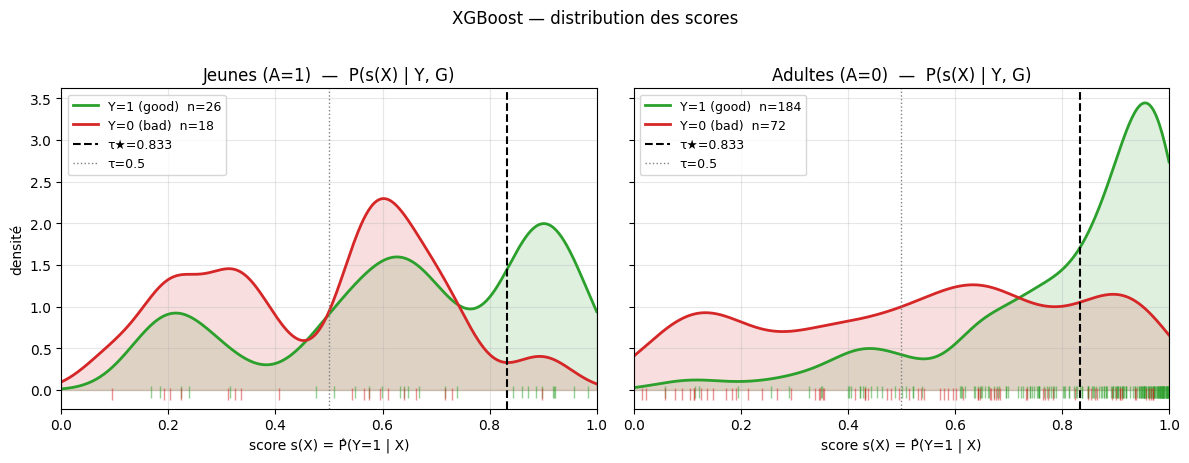

XGBoost — E[s(X) | Y, G] (et comparaison vs LogReg naturel) :
                                XGBoost       LogReg         Δ
  Jeunes (A=1)       Y=1 (good)      0.652        0.705    -0.054  (n=26)
  Jeunes (A=1)       Y=0 (bad)      0.479        0.484    -0.005  (n=18)
  Adultes (A=0)      Y=1 (good)      0.809        0.784    +0.026  (n=184)
  Adultes (A=0)      Y=0 (bad)      0.544        0.512    +0.032  (n=72)


In [573]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde                                                                                                     

A_arr = np.asarray(A_test)                                                                                                               
y_arr = np.asarray(y_test)
p     = np.asarray(proba_test_xgb)                                                                                                       
                
TAU = 5/6                                                                                                                                
groups = {1: "Jeunes (A=1)", 0: "Adultes (A=0)"}
colors_y = {1: "C2", 0: "C3"}                                                                                                            
labels_y = {1: "Y=1 (good)", 0: "Y=0 (bad)"}
xs = np.linspace(0, 1, 400)                                                                                                              

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)                                                                           
fig.suptitle("XGBoost — distribution des scores", fontsize=12, y=1.02)
                                                                                                                                        
for ax, (g_val, g_name) in zip(axes, groups.items()):
    mask_g = (A_arr == g_val)                                                                                                            
    for y_val in [1, 0]:
        mask = mask_g & (y_arr == y_val)                                                                                                 
        scores = p[mask]
        n = mask.sum()                                                                                                                   
        kde = gaussian_kde(scores, bw_method=0.25)
        ax.plot(xs, kde(xs), color=colors_y[y_val], lw=2,                                                                                
                label=f"{labels_y[y_val]}  n={n}")
        ax.fill_between(xs, kde(xs), alpha=0.15, color=colors_y[y_val])                                                                  
        ax.plot(scores, np.full_like(scores, -0.05) + (0.03 if y_val == 1 else 0),
                "|", color=colors_y[y_val], alpha=0.5, markersize=8)                                                                     
    ax.axvline(TAU, color="k", ls="--", lw=1.5, label=f"τ★={TAU:.3f}")
    ax.axvline(0.5, color="gray", ls=":", lw=1, label="τ=0.5")                                                                           
    ax.set_title(f"{g_name}  —  P(s(X) | Y, G)")                                                                                         
    ax.set_xlabel("score s(X) = P̂(Y=1 | X)")                                                                                             
    ax.set_xlim(0, 1)                                                                                                                    
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.3)                                                                                                                   
                
axes[0].set_ylabel("densité")                                                                                                            
plt.tight_layout()
plt.show()                                                                                                                               
                
print("XGBoost — E[s(X) | Y, G] (et comparaison vs LogReg naturel) :")                                                                   
print(f"{'':28s} {'XGBoost':>10s}   {'LogReg':>10s}   {'Δ':>7s}")
for g_val, g_name in groups.items():                                                                                                     
    for y_val in [1, 0]:
        mask = (A_arr == g_val) & (y_arr == y_val)                                                                                       
        m_xgb = proba_test_xgb[mask].mean()                                                                                              
        m_log = proba_test[mask].mean()
        print(f"  {g_name:18s} {labels_y[y_val]:8s} "                                                                                    
            f"{m_xgb:10.3f}   {m_log:10.3f}   {m_xgb - m_log:+7.3f}  (n={mask.sum()})")     

Le xgboost ne semble pas résoudre le problème de chevauchement des distributions chez les jeunes. Bien que les performances globales de ranking soient légèrement améliorées, l’analyse des densités révèle que les distributions de scores des jeunes \(Y=1\) et \(Y=0\) restent fortement chevauchées dans la région du seuil de décision. Le modèle conserve une capacité d’ordonnancement global, mais ne parvient pas à mieux séparer les bons et mauvais jeunes clients dans la zone critique pour la décision de crédit.

Ce résultat renforce l’hypothèse d’une limite principalement informationnelle des variables disponibles.

Jeunes en zone [0.5, 0.833) : 18


,i_test,score s,Y réel,Y voisins (liste),P(Y=1) voisins,Std voisins,Distance moy.
6,170,0.593,0,"[0, 1, 1, 1, 1]",0.80,0.40,3.67
8,200,0.613,1,"[1, 1, 0, 1, 1]",0.80,0.40,3.99
16,274,0.655,1,"[0, 1, 0, 1, 1]",0.60,0.49,5.35
13,263,0.658,0,"[1, 1, 1, 1, 0]",0.80,0.40,5.49
10,233,0.664,0,"[0, 0, 0, 1, 0]",0.20,0.40,5.28
5,143,0.676,1,"[1, 1, 1, 1, 1]",1.00,0.00,6.03
17,297,0.686,0,"[1, 0, 0, 1, 1]",0.60,0.49,4.73
12,260,0.690,1,"[1, 1, 0, 1, 1]",0.80,0.40,4.65
1,56,0.690,0,"[1, 0, 1, 0, 0]",0.40,0.49,5.25
14,265,0.695,1,"[0, 1, 0, 1, 1]",0.60,0.49,5.08


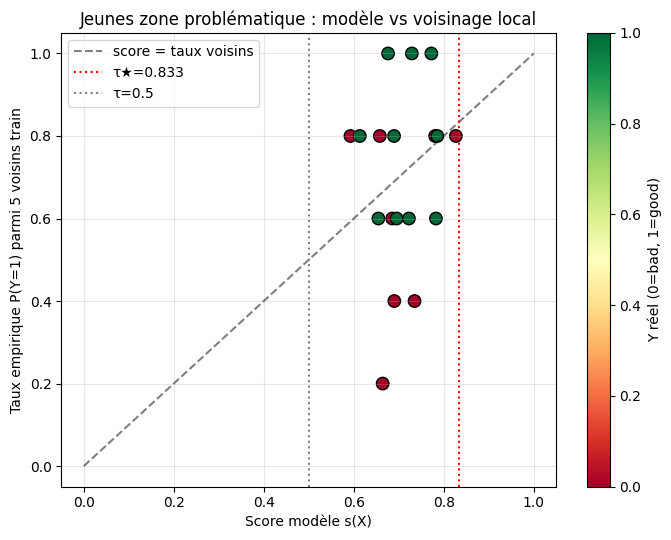

Score moyen modèle (jeunes zone)    : 0.709
Taux Y=1 moyen voisins train (k=5) : 0.700
Taux Y=1 réel observé (test)         : 0.556  (n=18)


In [574]:
import numpy as np
import pandas as pd                                                                                                                      
from sklearn.neighbors import NearestNeighbors
                                                                                                                                        
# ============================================================                                                                           
# 1. Espace features standardisé (post-preprocessing)
# ============================================================                                                                           
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)                                                                                            
if hasattr(X_train_proc, "toarray"):                                                                                                     
    X_train_proc = X_train_proc.toarray()                                                                                                
    X_test_proc  = X_test_proc.toarray()                                                                                                 
                                                                                                                                        
# StandardScaler "à la volée" sur le train pour distance euclidienne homogène                                                            
mu = X_train_proc.mean(axis=0)                                                                                                           
sd = X_train_proc.std(axis=0); sd[sd == 0] = 1.0                                                                                         
X_train_std = (X_train_proc - mu) / sd                                                                                                   
X_test_std  = (X_test_proc  - mu) / sd
                                                                                                                                        
# ============================================================
# 2. Sélection des jeunes en zone problématique                                                                                          
# ============================================================
A_test_arr = np.asarray(A_test)
y_test_arr = np.asarray(y_test)                                                                                                          
y_train_arr = np.asarray(y_train)
p = np.asarray(proba_test)                                                                                                               
                
TAU_LOW, TAU_HIGH = 0.5, 5/6                                                                                                             
mask_zone = (A_test_arr == 1) & (p >= TAU_LOW) & (p < TAU_HIGH)
idx_zone = np.where(mask_zone)[0]                                                                                                        
print(f"Jeunes en zone [{TAU_LOW}, {TAU_HIGH:.3f}) : {len(idx_zone)}")
                                                                                                                                        
# ============================================================
# 3. KNN : voisins dans le TRAIN (référence "vérité")                                                                                    
# ============================================================                                                                           
K = 5
knn = NearestNeighbors(n_neighbors=K, metric="euclidean").fit(X_train_std)                                                               
dists, neigh_idx = knn.kneighbors(X_test_std[idx_zone])                                                                                  

# ============================================================                                                                           
# 4. Pour chaque jeune zone : dispersion Y voisins vs son score
# ============================================================                                                                           
rows = []       
for k, i in enumerate(idx_zone):                                                                                                         
    y_neigh = y_train_arr[neigh_idx[k]]
    rows.append({                                                                                                                        
        "i_test":   i,
        "score s":  p[i],                                                                                                                
        "Y réel":   int(y_test_arr[i]),
        "Y voisins (liste)": y_neigh.tolist(),                                                                                           
        "P(Y=1) voisins":    y_neigh.mean(),                                                                                             
        "Std voisins":       y_neigh.std(),                                                                                              
        "Distance moy.":     dists[k].mean(),                                                                                            
    })                                                                                                                                   
df_zone = pd.DataFrame(rows).sort_values("score s")
                                                                                                                                        
display(df_zone.style                                                                                                                    
        .format({"score s": "{:.3f}", "P(Y=1) voisins": "{:.2f}",
                    "Std voisins": "{:.2f}", "Distance moy.": "{:.2f}"})                                                                  
        .set_caption(f"Jeunes en zone [{TAU_LOW}, {TAU_HIGH:.3f}) — voisinage local (k={K})"))
                                                                                                                                        
# ============================================================
# 5. Synthèse : score modèle vs taux empirique chez les voisins                                                                          
# ============================================================                                                                           
import matplotlib.pyplot as plt
                                                                                                                                        
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(df_zone["score s"], df_zone["P(Y=1) voisins"],                                                                          
                c=df_zone["Y réel"], cmap="RdYlGn", vmin=0, vmax=1,                                                                     
                s=80, edgecolor="k")                                                                                                    
plt.plot([0,1], [0,1], "k--", alpha=0.5, label="score = taux voisins")                                                                   
plt.axvline(TAU_HIGH, color="red", ls=":", label=f"τ★={TAU_HIGH:.3f}")                                                                   
plt.axvline(TAU_LOW,  color="gray", ls=":", label=f"τ={TAU_LOW}")                                                                        
plt.xlabel("Score modèle s(X)")                                                                                                          
plt.ylabel(f"Taux empirique P(Y=1) parmi {K} voisins train")                                                                             
plt.title("Jeunes zone problématique : modèle vs voisinage local")                                                                       
plt.colorbar(sc, label="Y réel (0=bad, 1=good)")                                                                                         
plt.legend()                                                                                                                             
plt.grid(alpha=0.3)                                                                                                                      
plt.tight_layout()
plt.show()                                                                                                                               
                
# Stats agrégées                                                                                                                         
mean_score = df_zone["score s"].mean()
mean_neigh = df_zone["P(Y=1) voisins"].mean()                                                                                            
mean_y     = df_zone["Y réel"].mean()                                                                                                    
print(f"Score moyen modèle (jeunes zone)    : {mean_score:.3f}")
print(f"Taux Y=1 moyen voisins train (k={K}) : {mean_neigh:.3f}")                                                                        
print(f"Taux Y=1 réel observé (test)         : {mean_y:.3f}  (n={len(idx_zone)})")     

### XAI 

Task to do : 

1. Intégrer proprement le modèle baseline pour le cas 
2. Comment on calcule le cout pour la bande de randomisation comment on sait que c'est fiable 

In [593]:
# Préparation                                                                                                                            
X_train_proc = baseline.named_steps["preproc"].transform(X_train)                                                                        
X_test_proc  = baseline.named_steps["preproc"].transform(X_test)                                                                         
if hasattr(X_train_proc, "toarray"):
    X_train_proc, X_test_proc = X_train_proc.toarray(), X_test_proc.toarray()                                                            
                
feature_names = baseline.named_steps["preproc"].get_feature_names_out()                                                                  
explainer   = shap.LinearExplainer(baseline.named_steps["clf"], X_train_proc,
                                    feature_names=feature_names)                                                                          
shap_values = explainer(X_test_proc)                                                                                                     

# === Tableau SHAP global ===                                                                                                            
vals = shap_values.values
                                                                                                                                        
table = (pd.DataFrame({
    "Feature":           feature_names,                                                                                                  
    "|SHAP| moyen":      np.abs(vals).mean(axis=0),       # importance (= bar plot)
    "SHAP moyen signé":  vals.mean(axis=0),               # direction moyenne                                                            
    "SHAP min":          vals.min(axis=0),                # effet le plus négatif observé                                                
    "SHAP max":          vals.max(axis=0),                # effet le plus positif observé                                                
    "SHAP std":          vals.std(axis=0),                # dispersion (= largeur beeswarm)                                              
}).assign(Sens=lambda d: np.where(d["SHAP moyen signé"] > 0, "↑ good", "↓ good"))
    .sort_values("|SHAP| moyen", ascending=False)                                                                                         
    .head(20).reset_index(drop=True))                                                                                                     
                                                                                                                                        
display(table.style                                                                                                                      
        .format({"|SHAP| moyen":"{:.3f}", "SHAP moyen signé":"{:+.3f}",
                    "SHAP min":"{:+.3f}", "SHAP max":"{:+.3f}", "SHAP std":"{:.3f}"})                                                     
        .background_gradient(subset=["|SHAP| moyen"], cmap="Blues")                                                                    
        .background_gradient(subset=["SHAP moyen signé"], cmap="RdYlGn", vmin=-0.5, vmax=0.5)                                          
        .set_caption("Top 20 variables — impact sur le log-odds (Y=1 = good)")) 

,Feature,|SHAP| moyen,SHAP moyen signé,SHAP min,SHAP max,SHAP std,Sens
0,cat__checking_status_no checking,0.681,+0.020,-0.528,+0.939,0.709,↑ good
1,cat__credit_history_critical/other existing credit,0.623,-0.020,-0.457,+1.017,0.673,↓ good
2,num__duration,0.386,-0.001,-2.099,+0.722,0.507,↓ good
3,cat__housing_rent,0.334,+0.057,-0.832,+0.235,0.397,↑ good
4,cat__personal_status_male single,0.291,+0.002,-0.324,+0.265,0.293,↑ good
5,cat__housing_own,0.279,-0.009,-0.199,+0.488,0.307,↓ good
6,cat__purpose_new car,0.274,-0.003,-0.620,+0.175,0.331,↓ good
7,num__existing_credits,0.239,-0.010,-0.827,+0.175,0.265,↓ good
8,cat__savings_status_no known savings,0.234,-0.011,-0.156,+0.521,0.277,↓ good
9,cat__property_magnitude_no known property,0.229,-0.066,-0.885,+0.098,0.366,↓ good


In [594]:
A_arr = np.asarray(A_test)                                                                                                 
mask_y = (A_arr == 1)   # Jeunes
mask_a = (A_arr == 0)   # Adultes                                                                                          
                                                                                                                            
vals = shap_values.values
                                                                                                                            
def stats(mask):
    v = vals[mask]
    return {
        "|SHAP| moyen": np.abs(v).mean(axis=0),
        "SHAP moyen signé": v.mean(axis=0),                                                                                
    }
                                                                                                                            
s_y, s_a = stats(mask_y), stats(mask_a)                                                                                    

cmp = pd.DataFrame({                                                                                                       
    "Feature":          feature_names,
    "|SHAP| Jeunes":    s_y["|SHAP| moyen"],                                                                               
    "|SHAP| Adultes":   s_a["|SHAP| moyen"],
    "SHAP signé Jeunes":  s_y["SHAP moyen signé"],                                                                         
    "SHAP signé Adultes": s_a["SHAP moyen signé"],
})                                                                                                                         
cmp["Δ |SHAP|"]      = cmp["|SHAP| Jeunes"] - cmp["|SHAP| Adultes"]
cmp["Δ SHAP signé"]  = cmp["SHAP signé Jeunes"] - cmp["SHAP signé Adultes"]                                                
cmp["|SHAP| moyen"]  = (cmp["|SHAP| Jeunes"] + cmp["|SHAP| Adultes"]) / 2                                                  
                                                                                                                            
cmp = cmp.sort_values("|SHAP| moyen", ascending=False).head(20).reset_index(drop=True)                                     
                
display(cmp[["Feature", "|SHAP| Jeunes", "|SHAP| Adultes", "Δ |SHAP|",                                                     
            "SHAP signé Jeunes", "SHAP signé Adultes", "Δ SHAP signé"]]
        .style                                                                                                             
        .format({"|SHAP| Jeunes":"{:.3f}", "|SHAP| Adultes":"{:.3f}",
                "Δ |SHAP|":"{:+.3f}",                                                                                     
                "SHAP signé Jeunes":"{:+.3f}", "SHAP signé Adultes":"{:+.3f}",
                "Δ SHAP signé":"{:+.3f}"})                                                                                
        .background_gradient(subset=["Δ |SHAP|"], cmap="RdBu_r", vmin=-0.3, vmax=0.3)
        .background_gradient(subset=["Δ SHAP signé"], cmap="RdBu_r", vmin=-0.3, vmax=0.3)                                  
        .set_caption("SHAP par groupe — Jeunes vs Adultes (top 20 par importance moyenne)")) 

,Feature,|SHAP| Jeunes,|SHAP| Adultes,Δ |SHAP|,SHAP signé Jeunes,SHAP signé Adultes,Δ SHAP signé
0,cat__checking_status_no checking,0.575,0.700,-0.125,-0.361,+0.085,-0.446
1,cat__credit_history_critical/other existing credit,0.533,0.638,-0.105,-0.256,+0.021,-0.277
2,cat__housing_rent,0.520,0.302,+0.217,-0.274,+0.114,-0.388
3,num__duration,0.376,0.388,-0.012,+0.034,-0.007,+0.041
4,cat__housing_own,0.343,0.268,+0.075,+0.144,-0.036,+0.180
5,cat__personal_status_male single,0.309,0.288,+0.021,-0.177,+0.033,-0.209
6,cat__purpose_new car,0.236,0.281,-0.045,+0.066,-0.015,+0.081
7,cat__savings_status_no known savings,0.222,0.236,-0.014,-0.033,-0.008,-0.025
8,num__existing_credits,0.210,0.244,-0.035,+0.061,-0.022,+0.084
9,num__installment_commitment,0.219,0.222,-0.003,+0.069,+0.005,+0.064


Jeunes dans [0.5, 0.833) : n = 18  (Y=1 : 10, Y=0 : 8)


,Feature,|SHAP| zone,SHAP signé zone,SHAP moyen Y=1,SHAP moyen Y=0,Δ Y=1 − Y=0
0,cat__credit_history_critical/other existing credit,0.519,-0.293,-0.162,-0.457,+0.295
1,cat__housing_rent,0.467,-0.180,-0.299,-0.032,-0.267
2,cat__personal_status_male mar/wid,0.162,+0.102,+0.010,+0.217,-0.207
3,cat__foreign_worker_yes,0.163,+0.051,+0.139,-0.059,+0.198
4,cat__checking_status_>=200,0.131,+0.053,+0.131,-0.044,+0.175
5,cat__housing_own,0.311,+0.068,+0.144,-0.027,+0.172
6,cat__employment_>=7,0.149,-0.044,+0.013,-0.116,+0.129
7,num__installment_commitment,0.209,+0.026,-0.023,+0.088,-0.111
8,cat__savings_status_no known savings,0.217,-0.043,-0.088,+0.014,-0.102
9,cat__property_magnitude_no known property,0.142,+0.044,-0.000,+0.098,-0.098


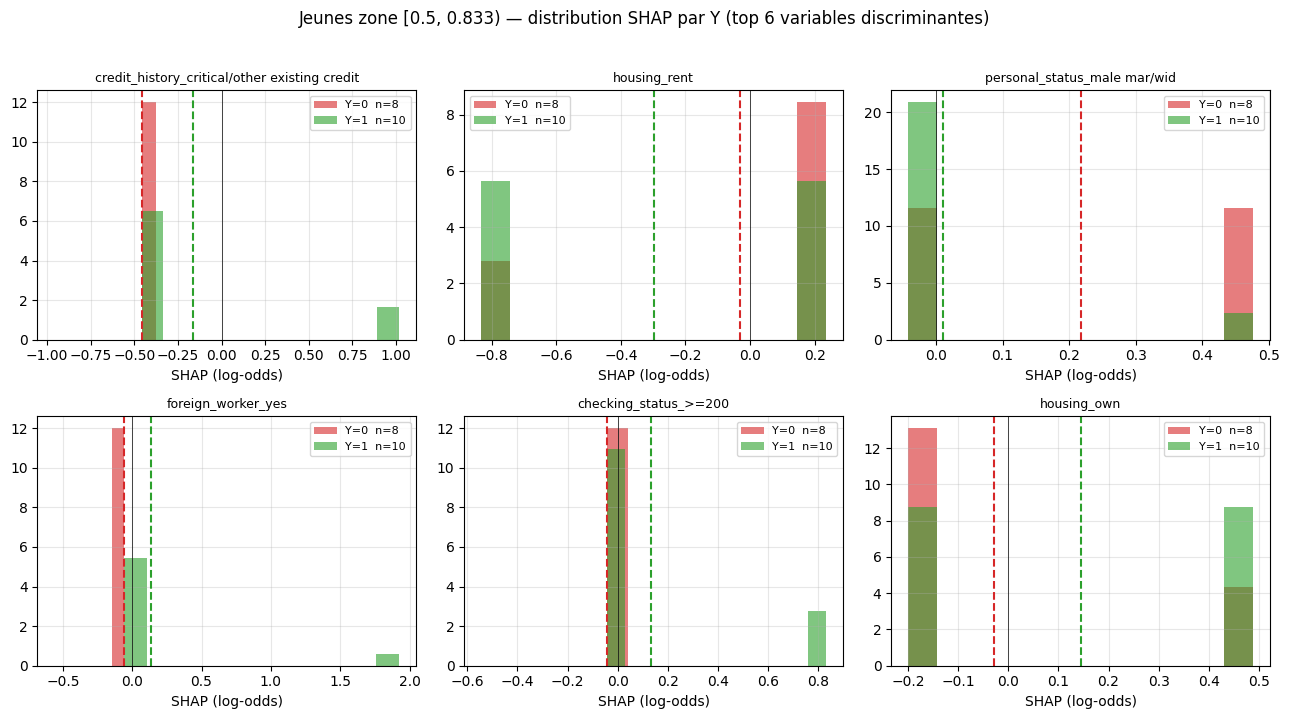

In [595]:
# === Définition de la zone & des masques ===                                                                              
TAU_LOW, TAU_HIGH = 0.5, 5/6                                                                                               
A_arr = np.asarray(A_test)                                                                                                 
y_arr = np.asarray(y_test)                                                                                               
p     = np.asarray(proba_test)                                                                                             
                                                                                                                        
mask_zone = (A_arr == 1) & (p >= TAU_LOW) & (p < TAU_HIGH)                                                                 
mask_zone_pos = mask_zone & (y_arr == 1)   # jeunes zone Y=1 (vrais bons)                                                
mask_zone_neg = mask_zone & (y_arr == 0)   # jeunes zone Y=0 (vrais mauvais)                                               
                                                                                                                            
n_zone = mask_zone.sum()                                                                                                   
n_pos  = mask_zone_pos.sum()                                                                                               
n_neg  = mask_zone_neg.sum()                                                                                               
print(f"Jeunes dans [{TAU_LOW}, {TAU_HIGH:.3f}) : n = {n_zone}  "                                                        
    f"(Y=1 : {n_pos}, Y=0 : {n_neg})")                                                                                   
                                                                                                                            
# === (i) Direction moyenne dans la zone + (ii) Pouvoir discriminant local ===                                             
vals = shap_values.values                                                                                                  
                                                                                                                        
# (i) SHAP signé moyen sur l'ensemble des jeunes-zone                                                                      
shap_signed_zone = vals[mask_zone].mean(axis=0)                                                                          
shap_abs_zone    = np.abs(vals[mask_zone]).mean(axis=0)                                                                    
                                                                                                                            
# (ii) Pouvoir discriminant = différence des moyennes SHAP entre Y=1 et Y=0                                                
shap_mean_pos = vals[mask_zone_pos].mean(axis=0) if n_pos > 0 else np.zeros(vals.shape[1])                                 
shap_mean_neg = vals[mask_zone_neg].mean(axis=0) if n_neg > 0 else np.zeros(vals.shape[1])                                 
discrim       = shap_mean_pos - shap_mean_neg     # > 0 : variable sépare bien Y=1 de Y=0                                  
                                                                                                                            
zone_df = pd.DataFrame({                                                                                                   
    "Feature":            feature_names,                                                                                   
    "|SHAP| zone":        shap_abs_zone,                  # importance locale                                              
    "SHAP signé zone":    shap_signed_zone,               # (i) direction moyenne                                          
    "SHAP moyen Y=1":     shap_mean_pos,
    "SHAP moyen Y=0":     shap_mean_neg,                                                                                   
    "Δ Y=1 − Y=0":        discrim,                        # (ii) pouvoir discriminant                                    
})                                                                                                                         
                                                                                                                        
# Tri par pouvoir discriminant absolu                                                                                      
zone_df["|Δ Y=1−Y=0|"] = zone_df["Δ Y=1 − Y=0"].abs()                                                                    
top = zone_df.sort_values("|Δ Y=1−Y=0|", ascending=False).head(15).reset_index(drop=True)                                  
                                                                                                                            
display(top[["Feature", "|SHAP| zone", "SHAP signé zone",                                                                  
            "SHAP moyen Y=1", "SHAP moyen Y=0", "Δ Y=1 − Y=0"]]                                                           
        .style                                                                                                             
        .format({"|SHAP| zone":"{:.3f}", "SHAP signé zone":"{:+.3f}",                                                    
                "SHAP moyen Y=1":"{:+.3f}", "SHAP moyen Y=0":"{:+.3f}",                                                   
                "Δ Y=1 − Y=0":"{:+.3f}"})                                                                                 
        .background_gradient(subset=["SHAP signé zone"], cmap="RdYlGn", vmin=-0.5, vmax=0.5)                               
        .background_gradient(subset=["Δ Y=1 − Y=0"],     cmap="RdYlGn", vmin=-0.5, vmax=0.5)                               
        .set_caption(f"Jeunes en zone [{TAU_LOW}, {TAU_HIGH:.3f}) — "                                                      
                    f"top 15 par |pouvoir discriminant local|"))                                                          
                                                                                                                            
# === Visualisation : distribution SHAP par Y pour les top variables discriminantes ===                                    
import matplotlib.pyplot as plt                                                                                            
                                                                                                                        
top_features_idx = top.index[:6]  # top 6 plus discriminantes                                                              
top_features_names = top["Feature"].iloc[:6].tolist()                                                                    
                                                                                                                            
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)                                                              
for ax, fname in zip(axes.flat, top_features_names):                                                                       
    fidx = np.where(feature_names == fname)[0][0]                                                                          
    v_pos = vals[mask_zone_pos, fidx]                                                                                    
    v_neg = vals[mask_zone_neg, fidx]                                                                                      

    ax.hist(v_neg, bins=12, color="C3", alpha=0.6, label=f"Y=0  n={n_neg}", density=True)                                  
    ax.hist(v_pos, bins=12, color="C2", alpha=0.6, label=f"Y=1  n={n_pos}", density=True)                                
    ax.axvline(v_neg.mean() if n_neg else 0, color="C3", ls="--", lw=1.5)                                                  
    ax.axvline(v_pos.mean() if n_pos else 0, color="C2", ls="--", lw=1.5)                                                  
    ax.axvline(0, color="k", lw=0.5)                                                                                       
    ax.set_title(fname.replace("cat__","").replace("num__",""), fontsize=9)                                                
    ax.set_xlabel("SHAP (log-odds)")                                                                                       
    ax.legend(fontsize=8)                                                                                                
    ax.grid(alpha=0.3)                                                                                                     
                                                                                                                        
fig.suptitle(f"Jeunes zone [{TAU_LOW}, {TAU_HIGH:.3f}) — distribution SHAP par Y "                                         
            f"(top 6 variables discriminantes)", y=1.02)                                                                
plt.tight_layout()                                                                                                         
plt.show()    